# Consumo de alcohol en la ENCSPA 2019
## Introducción y contexto

La Encuesta Nacional de Consumo de Sustancias Psicoactivas en Población General
(ENCSPA) del DANE estudia población de 12–65 años dentro de su cobertura
geográfica. Este EDA utiliza 49,756 personas seleccionadas y vincula entorno,
inicio, consumo y consecuencias para generar hipótesis de tesis.

El interés no se limita a haber bebido: también importa la cantidad en una ocasión,
la edad de inicio y las consecuencias reportadas. Los resultados ayudan a identificar
grupos para investigar; por sí solos no prueban causalidad ni diagnostican dependencia.
[Fuente y documentación DANE](https://microdatos.dane.gov.co/catalog/680/related_materials).

## Metodología

**Unidad de observación y ponderación.** Una fila corresponde a una persona
entrevistada, seleccionada dentro del hogar. FEX_C, conservado como fex_c, es
su factor de expansión: al estimar porcentajes poblacionales, las filas no tienen
necesariamente el mismo peso. El porcentaje ponderado divide la suma de pesos
de una categoría entre la suma de pesos de las respuestas válidas de su base.

Los grupos con **n < 30** (ver columna **n_valido**) se interpretan con cautela;
no se marcan individualmente para no saturar las tablas.

Se aplican filtros de pregunta y se distinguen porcentajes condicionales de
prevalencias generales. Los nulos pueden ser saltos estructurales; nunca se
recodifican todos como No. Media y dispersión muestrales se distinguen de las
ponderadas. La ayuda de tabulación está en [eda_indicadores.py](../src/eda_indicadores.py).

> **Inferencia exploratoria:** los chi-cuadrado de SciPy y V de Cramér usan conteos
> sin ponderar. No ajustan por estratos y conglomerados; pueden exagerar la
> significancia. Los porcentajes ponderados tampoco incluyen aquí intervalos
> basados en el diseño. Las asociaciones y los p-valores no son pruebas finales
> de las hipótesis. Para tablas categóricas, el paso posterior es Rao–Scott;
> para edad de inicio, un contraste de medias o regresión con diseño muestral.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact

pd.set_option('display.max_rows', 14)
pd.set_option('display.max_columns', 12)
pd.set_option('display.precision', 2)
ruta = Path('data/processed/df_master.parquet')
if not ruta.exists():
    ruta = Path('../data/processed/df_master.parquet')
llaves = ['directorio', 'secuencia_encuesta', 'secuencia_p', 'orden']
df = pd.read_parquet(ruta, columns=llaves + ['fex_c', 'sexo', 'edad', 'd2_05'] + ['d_02', 'd_11_b', 'd_12_a', 'd_12_a_a', 'r_01', 'r_03', 'r_08_b', 'r_02', 'r_04', 'r_09', 's_01', 's_02_b', 's_02_b_01']
    + ['f_01', 'f_01_cual', 'f_02', 'f_02_cual', 'f_03', 'f_04', 'f_05', 'f_06', 'f_07', 'f_08', 'f_09', 'f_10_a', 'f_10_b', 'f_10_c', 'f_10_d', 'f_10_e', 'f_10_f', 'f_10_g', 'f_10_h', 'f_10_i', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_20_cual', 'f_21_cual'])
assert not df.duplicated(llaves).any(), 'Hay personas duplicadas'
assert df[llaves].notna().all().all(), 'Hay llaves incompletas'
assert (df.fex_c.gt(0) & np.isfinite(df.fex_c)).all(), 'Revisar pesos'
assert df.edad.between(12, 65).all(), 'Revisar edad seleccionada'
df = df.rename(columns={
    'd_02': 'D_02 · Actividad principal',
    'd_11_b': 'D_11_B · Riesgo del consumo frecuente',
    'd_12_a': 'D_12_A · Alcohol como problema del barrio',
    'd_12_a_a': 'D_12_A_A · Gravedad del problema',
    'r_01': 'R_01 · Accidente laboral',
    'r_03': 'R_03 · Días de ausencia',
    'r_08_b': 'R_08_B · Alcohol en horario laboral',
    'r_02': 'R_02 · Sustancias antes del accidente',
    'r_04': 'R_04 · Ausencia por alcohol u otras sustancias',
    'r_09': 'R_09 · Menor rendimiento por sustancias',
    's_01': 'S_01 · Ha estado embarazada',
    's_02_b': 'S_02_B · Alcohol durante embarazo',
    's_02_b_01': 'S_02_B_01 · Frecuencia durante embarazo',
    'sexo': 'Sexo', 'edad': 'Edad', 'd2_05': 'Educación',
    'f_01': 'F_01 · Familiares que se emborrachan frecuentemente',
    'f_01_cual': 'F_01_CUAL · Cantidad de familiares (categoría)',
    'f_02': 'F_02 · Amigos que se emborrachan frecuentemente',
    'f_02_cual': 'F_02_CUAL · Cantidad de amigos (categoría)',
    'f_03': 'F_03 · Consumo de alcohol alguna vez',
    'f_04': 'F_04 · Edad de inicio del consumo',
    'f_05': 'F_05 · Recencia del primer consumo',
    'f_06': 'F_06 · Consumo en últimos 12 meses',
    'f_07': 'F_07 · Consumo en últimos 30 días',
    'f_08': 'F_08 · Días de consumo en últimos 30 días',
    'f_09': 'F_09 · Días de embriaguez en últimos 30 días',
    'f_10_a': 'F_10_A · Cerveza',
    'f_10_b': 'F_10_B · Aguardiente',
    'f_10_c': 'F_10_C · Ron',
    'f_10_d': 'F_10_D · Whisky',
    'f_10_e': 'F_10_E · Brandy, coñac, vodka, ginebra',
    'f_10_f': 'F_10_F · Vino',
    'f_10_g': 'F_10_G · Chicha, guarapo, chirrinchi',
    'f_10_h': 'F_10_H · Alcohol industrial o medicinal mezclado',
    'f_10_i': 'F_10_I · Otra bebida',
    'f_11': 'F_11 · Consumo por vía distinta a la oral',
    'f_12': 'F_12 · Frecuencia de consumo en 12 meses',
    'f_13': 'F_13 · Tragos en un día habitual (categoría)',
    'f_14': 'F_14 · Seis o más tragos en un día',
    'f_15': 'F_15 · Imposibilidad de parar de beber',
    'f_16': 'F_16 · Incumplimiento de actividades por beber',
    'f_17': 'F_17 · Necesidad de beber en ayunas',
    'f_18': 'F_18 · Culpa o remordimientos',
    'f_19': 'F_19 · No recordar la noche anterior',
    'f_20': 'F_20 · Lesiones propias o a terceros',
    'f_21': 'F_21 · Preocupación de otras personas',
    'f_20_cual': 'F_20_CUAL · Recencia de las lesiones',
    'f_21_cual': 'F_21_CUAL · Recencia de la preocupación'
})
df['Sexo'] = df['Sexo'].map({1: 'Hombre', 2: 'Mujer'})
df['Educación'] = pd.Categorical(df['Educación'].map({
    1: 'Ninguno / preescolar', 2: 'Ninguno / preescolar', 3: 'Primaria',
    4: 'Secundaria', 5: 'Media', 6: 'Técnica/tecnológica', 7: 'Universitaria',
    8: 'Postgrado'}), categories=['Ninguno / preescolar', 'Primaria', 'Secundaria',
    'Media', 'Técnica/tecnológica', 'Universitaria', 'Postgrado'], ordered=True)
df['grupo_edad'] = pd.cut(df['Edad'], [11, 17, 25, 35, 45, 55, 65],
    labels=['12–17', '18–25', '26–35', '36–45', '46–55', '56–65'])
print(f'{len(df):,} personas; {len(df.columns)} columnas; sin llaves duplicadas.')
assert 'Educación' in df and 'fex_c' in df

49,756 personas; 55 columnas; sin llaves duplicadas.


In [2]:
import sys
sys.path.insert(0, str(ruta.resolve().parents[2] / 'src'))
from eda_indicadores import pct_ponderado

## Resultados descriptivos
### Perfil sociodemográfico y faltantes

Educación se presenta en orden lógico. Se agrupan Ninguno y Preescolar por la
escasez de casos de Preescolar (28 entre consumidores anuales); la nueva categoría
no distingue esos dos niveles. No sabe/no informa se muestra en el perfil pero
se excluye del cruce educativo.

La tabla de faltantes muestra nulos sobre **toda la muestra**, incluyendo saltos
estructurales: no es una tasa de no respuesta. Los códigos especiales siguen
excluyéndose en cada celda. Las tres columnas numéricas no pasan por pct_ponderado.

**Nombres de columnas:** el maestro contiene d2_05 y una etiqueta derivada
nivel_educativo. Este notebook lee d2_05 y la renombra Educación; todos los
cruces usan Educación. El factor se mantiene como fex_c.


In [3]:
for variable in ['Sexo', 'grupo_edad', 'Educación']:
    perfil = df[[variable, 'fex_c']].copy()
    perfil[variable] = perfil[variable].astype(object).fillna('Sin información')
    tabla = pct_ponderado(perfil, variable)
    if variable == 'Educación':
        tabla = tabla.reindex(['Ninguno / preescolar', 'Primaria', 'Secundaria', 'Media',
            'Técnica/tecnológica', 'Universitaria', 'Postgrado', 'Sin información'])
    display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

faltantes = df.filter(regex='^[FDRS]_').isna().sum().to_frame('n nulos (incluye saltos)')
faltantes['% de toda la muestra'] = 100*faltantes.iloc[:,0]/len(df)
faltantes['n no nulos'] = len(df)-faltantes.iloc[:,0]
with pd.option_context('display.max_rows', 60):
    display((faltantes.round(2)).style.format(precision=1, thousands=',', na_rep='—'))
perfil_sexo = pct_ponderado(df, 'Sexo')
print(f"Hombres: {perfil_sexo.loc['Hombre', 'pct_muestral']:.2f}% muestral frente a "
      f"{perfil_sexo.loc['Hombre', 'pct_ponderado']:.2f}% ponderado. "
      "Los pesos aumentan su participación respecto de la muestra; "
      "esto explica parte de la diferencia entre resultados muestrales y ponderados.")

,pct_muestral,pct_ponderado,n_valido
Sexo,,,
Hombre,42.0,48.2,"20,898"
Mujer,58.0,51.8,"28,858"


,pct_muestral,pct_ponderado,n_valido
grupo_edad,,,
12–17,7.2,12.8,"3,559"
18–25,17.7,18.2,"8,822"
26–35,22.8,21.7,"11,341"
36–45,18.6,18.4,"9,252"
46–55,17.0,15.5,"8,445"
56–65,16.8,13.4,"8,337"


,pct_muestral,pct_ponderado,n_valido
Educación,,,
Ninguno / preescolar,1.4,1.0,688
Primaria,13.7,12.2,"6,794"
Secundaria,16.1,18.5,"8,009"
Media,29.9,31.0,"14,884"
Técnica/tecnológica,17.0,16.1,"8,453"
Universitaria,17.6,17.2,"8,754"
Postgrado,4.3,4.0,"2,145"
Sin información,0.1,0.0,29


,n nulos (incluye saltos),% de toda la muestra,n no nulos
D_02 · Actividad principal,0,0.0,"49,756"
D_11_B · Riesgo del consumo frecuente,0,0.0,"49,756"
D_12_A · Alcohol como problema del barrio,0,0.0,"49,756"
D_12_A_A · Gravedad del problema,"17,518",35.2,"32,238"
R_01 · Accidente laboral,"21,065",42.3,"28,691"
R_03 · Días de ausencia,"21,065",42.3,"28,691"
R_08_B · Alcohol en horario laboral,"21,065",42.3,"28,691"
R_02 · Sustancias antes del accidente,"48,726",97.9,"1,030"
R_04 · Ausencia por alcohol u otras sustancias,"47,102",94.7,"2,654"
R_09 · Menor rendimiento por sustancias,"21,065",42.3,"28,691"


Hombres: 42.00% muestral frente a 48.25% ponderado. Los pesos aumentan su participación respecto de la muestra; esto explica parte de la diferencia entre resultados muestrales y ponderados.


**Interpretación.** La muestra tiene 42.0% de hombres, frente a 48.25% tras ponderar: una diferencia de
**6.25 puntos porcentuales**. El peso corrige su participación relativa y puede cambiar
los resultados. La tabla de nulos mide ausencia de datos sobre toda la muestra:
no debe confundirse con no respuesta dentro de cada base.

### Exposición e inicio · sección F
### F_01–F_02 · Entorno familiar y social
Base: todas las personas. “Cuántos” solo entre quienes contestan Sí;
2 significa **dos o más**, no exactamente dos.

In [4]:
sub = df.loc[df['F_01 · Familiares que se emborrachan frecuentemente'].isin([1, 2])].copy()
sub['F_01 · Familiares que se emborrachan frecuentemente'] = sub['F_01 · Familiares que se emborrachan frecuentemente'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'F_01 · Familiares que se emborrachan frecuentemente')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

sub = df.loc[df['F_01 · Familiares que se emborrachan frecuentemente'].eq(1)].copy()
sub['F_01_CUAL · Cantidad de familiares (categoría)'] = sub['F_01_CUAL · Cantidad de familiares (categoría)'].map({1: 'Uno', 2: 'Dos o más'})
tabla = pct_ponderado(sub, 'F_01_CUAL · Cantidad de familiares (categoría)')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_01 · Familiares que se emborrachan frecuentemente,,,
No,66.0,65.9,"32,816"
Sí,34.0,34.1,"16,940"


,pct_muestral,pct_ponderado,n_valido
F_01_CUAL · Cantidad de familiares (categoría),,,
Dos o más,62.0,62.2,"10,506"
Uno,38.0,37.8,"6,434"


**Interpretación.** El 34.1% ponderado reporta familiares que se emborrachan frecuentemente.
Entre quienes reportan ese entorno, 62.2% identifica dos o más familiares.
La exposición familiar es común, pero esta tabla no muestra todavía si se relaciona
con el consumo propio; esa comparación se realiza en los cruces.

In [5]:
sub = df.loc[df['F_02 · Amigos que se emborrachan frecuentemente'].isin([1, 2])].copy()
sub['F_02 · Amigos que se emborrachan frecuentemente'] = sub['F_02 · Amigos que se emborrachan frecuentemente'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'F_02 · Amigos que se emborrachan frecuentemente')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

sub = df.loc[df['F_02 · Amigos que se emborrachan frecuentemente'].eq(1)].copy()
sub['F_02_CUAL · Cantidad de amigos (categoría)'] = sub['F_02_CUAL · Cantidad de amigos (categoría)'].map({1: 'Uno', 2: 'Dos o más'})
tabla = pct_ponderado(sub, 'F_02_CUAL · Cantidad de amigos (categoría)')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_02 · Amigos que se emborrachan frecuentemente,,,
No,57.5,58.3,"28,629"
Sí,42.5,41.7,"21,127"


,pct_muestral,pct_ponderado,n_valido
F_02_CUAL · Cantidad de amigos (categoría),,,
Dos o más,87.0,86.4,"18,371"
Uno,13.0,13.6,"2,756"


**Interpretación.** El 41.7% ponderado reporta amigos que se emborrachan, por encima del 34.1% familiar.
Entre quienes reportan amigos, 86.4% señala dos o más: el fenómeno suele involucrar
a varios integrantes de la red social. Esto motiva H2, sin establecer la dirección de la asociación.

### F_03–F_05 · Consumo alguna vez e inicio
    'f_03': 'F_03 · Consumo de alcohol alguna vez'
    'f_04': 'F_04 · Edad de inicio del consumo'
    'f_05': 'F_05 · Recencia del primer consumo'
F_03: todas las personas. F_04 y F_05: F_03 = Sí.
Edad de inicio válida: entero entre 1 y la edad actual. Se conservan edades
muy tempranas si cumplen la regla; no se descartan automáticamente.

Las edades de 1–4 años son registros sospechosos: se conservan, se cuentan y se presenta sensibilidad excluyéndolos. Los cuartiles ponderados usan la distribución empírica acumulada; la DE ponderada describe dispersión, no error estándar.

**Plausibilidad de inicios entre 1 y 4 años.** Los datos crudos contienen 85 casos
en ese rango. Como criterio de plausibilidad del consumo autónomo, requieren
revisión: podrían reflejar una ingesta accidental, una bebida suministrada por
un adulto o un error de recuerdo/reporte; el cuestionario no permite distinguirlo.
El corte de 5 años es una decisión operativa de sensibilidad, no un umbral
biológico validado ni una imposibilidad de exposición antes de esa edad.
No se modifica el dato crudo ni se excluyen esos casos del análisis principal;
solo se recalcula la media aparte para observar cuánto cambia.


In [6]:
sub = df.loc[df['F_03 · Consumo de alcohol alguna vez'].isin([1, 2])].copy()
sub['F_03 · Consumo de alcohol alguna vez'] = sub['F_03 · Consumo de alcohol alguna vez'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'F_03 · Consumo de alcohol alguna vez')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_03 · Consumo de alcohol alguna vez,,,
No,14.7,16.0,"7,315"
Sí,85.3,84.0,"42,441"


**Interpretación.** El 84.0% ponderado ha consumido alcohol alguna vez, frente al 85.3% muestral.
Esta medida indica exposición acumulada, no consumo actual ni consumo problemático.
Su alta proporción justifica separar ventanas temporales y formas de consumo.

F_04 · Edad de inicio del consumo


,Muestral (sin ponderar),Ponderado (FEX_C)
n válido,"42,441","42,441"
Media,18.1,17.8
DE descriptiva,4.6,4.4
Q1,15.0,15.0
Mediana,18.0,17.0
Q3,20.0,19.0
Mínimo,1.0,1.0
Máximo,61.0,61.0


Inicios de 1–4 años para revisión: 85
Media ponderada excluyendo 1–4 años: 17.8


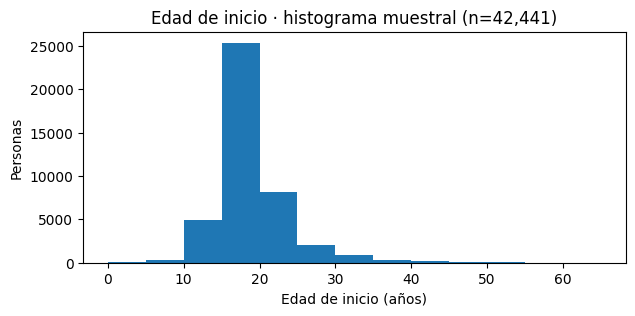

,pct_muestral,pct_ponderado,n_valido
F_05 · Recencia del primer consumo,,,
Hace más de 12 meses,95.8,94.7,"40,654"
Más de 30 días y menos de 12 meses,2.7,3.7,"1,132"
Últimos 30 días,1.5,1.6,655


In [7]:
inicio = df.loc[df['F_03 · Consumo de alcohol alguna vez'].eq(1)
    & df['F_04 · Edad de inicio del consumo'].between(1, 65) & df['F_04 · Edad de inicio del consumo'].le(df['Edad'])
    & df['F_04 · Edad de inicio del consumo'].eq(df['F_04 · Edad de inicio del consumo'].round())].copy()
sub = inicio.dropna(subset=['F_04 · Edad de inicio del consumo', 'fex_c']).copy()
sub = sub.sort_values('F_04 · Edad de inicio del consumo')
x = sub['F_04 · Edad de inicio del consumo'].to_numpy()
w = sub.fex_c.to_numpy()
media_w = np.average(x, weights=w)
cuartiles_w = x[np.searchsorted(np.cumsum(w), np.array([.25, .5, .75]) * w.sum())]
descriptivos = pd.DataFrame({
    'Muestral (sin ponderar)': [len(sub), x.mean(), np.std(x, ddof=1), *np.quantile(x, [.25,.5,.75]), x.min(), x.max()],
    'Ponderado (FEX_C)': [len(sub), media_w, np.sqrt(np.average((x-media_w)**2, weights=w)),
                        *cuartiles_w, x.min(), x.max()]
}, index=['n válido', 'Media', 'DE descriptiva', 'Q1', 'Mediana', 'Q3', 'Mínimo', 'Máximo'])
print('F_04 · Edad de inicio del consumo')
display((descriptivos.round(2)).style.format(precision=1, thousands=',', na_rep='—').format('{:,.0f}', subset=pd.IndexSlice[['n válido'], :]))

print('Inicios de 1–4 años para revisión:', inicio['F_04 · Edad de inicio del consumo'].between(1,4).sum())
sensibilidad = inicio.loc[inicio['F_04 · Edad de inicio del consumo'].ge(5)]
print('Media ponderada excluyendo 1–4 años:',
      round(np.average(sensibilidad['F_04 · Edad de inicio del consumo'], weights=sensibilidad.fex_c), 2))
ax = inicio['F_04 · Edad de inicio del consumo'].plot.hist(bins=np.arange(0, 66, 5),
    title=f'Edad de inicio · histograma muestral (n={len(inicio):,})', figsize=(7,3))
ax.set(xlabel='Edad de inicio (años)', ylabel='Personas')
fig = ax.figure
display(fig)
plt.close(fig)
sub = df.loc[df['F_03 · Consumo de alcohol alguna vez'].eq(1)].copy()
sub['F_05 · Recencia del primer consumo'] = sub['F_05 · Recencia del primer consumo'].map({1: 'Últimos 30 días', 2: 'Más de 30 días y menos de 12 meses', 3: 'Hace más de 12 meses'})
tabla = pct_ponderado(sub, 'F_05 · Recencia del primer consumo')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

**Interpretación.** La edad media de inicio es 17.77 años ponderada y 18.12 sin ponderar; la mediana
ponderada es 17. El histograma concentra inicios en adolescencia y adultez temprana.
Excluir solo en sensibilidad los 85 registros de 1–4 años cambia la media ponderada
a 17.80: poco impacto global, aunque persiste la necesidad de revisar esos registros.
En F_05 Recencia del primer consumo, 94.7% de los inicios ocurrió hace más de 12 meses.

### F_06–F_07 · Ventanas de consumo
F_06: consumo alguna vez; F_07: consumo en 12 meses. Se excluye 9 (no contesta).
Son porcentajes **condicionales a cada base**, no prevalencias poblacionales.

In [8]:
sub = df.loc[df['F_03 · Consumo de alcohol alguna vez'].eq(1)].copy()
sub['F_06 · Consumo en últimos 12 meses'] = sub['F_06 · Consumo en últimos 12 meses'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'F_06 · Consumo en últimos 12 meses')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
sub['F_07 · Consumo en últimos 30 días'] = sub['F_07 · Consumo en últimos 30 días'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'F_07 · Consumo en últimos 30 días')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_06 · Consumo en últimos 12 meses,,,
No,37.8,35.0,"16,026"
Sí,62.2,65.0,"26,363"


,pct_muestral,pct_ponderado,n_valido
F_07 · Consumo en últimos 30 días,,,
No,44.8,44.8,"11,813"
Sí,55.2,55.2,"14,536"


**Interpretación.** Entre quienes consumieron alguna vez y respondieron F_06, el 65.0% ponderado
consumió en 12 meses. Entre consumidores anuales con F_07 válido, el 55.2% consumió
en 30 días. Los denominadores cambian: no son prevalencias sobre las 49,756 personas.

### F_08–F_09 · Días de consumo y embriaguez
Base: consumo en 30 días. Rangos: F_08 de 1–30 y F_09 de 0–30.
El código observado 99 en F_08 se excluye; no equivale a 99 días.

Las columnas distinguen estadísticos muestrales de ponderados; los histogramas muestran personas sin ponderar.

F_08 · Días de consumo en últimos 30 días


,Muestral (sin ponderar),Ponderado (FEX_C)
n válido,"14,501","14,501"
Media,2.6,2.5
DE descriptiva,3.2,3.0
Q1,1.0,1.0
Mediana,2.0,2.0
Q3,3.0,3.0
Mínimo,1.0,1.0
Máximo,30.0,30.0


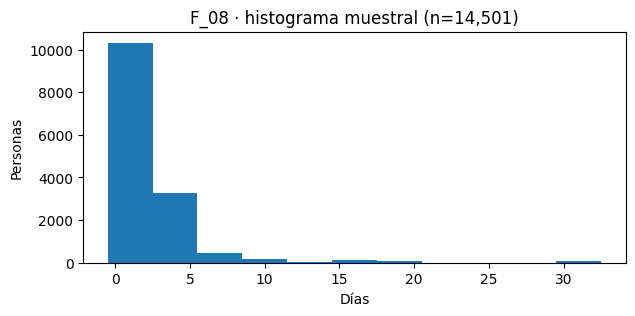

F_09 · Días de embriaguez en últimos 30 días


,Muestral (sin ponderar),Ponderado (FEX_C)
n válido,"14,536","14,536"
Media,0.5,0.5
DE descriptiva,1.5,1.4
Q1,0.0,0.0
Mediana,0.0,0.0
Q3,1.0,0.0
Mínimo,0.0,0.0
Máximo,30.0,30.0


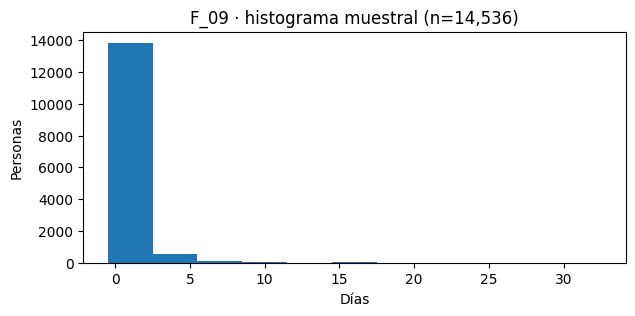

In [9]:
sub = df.loc[df['F_07 · Consumo en últimos 30 días'].eq(1) & df['F_08 · Días de consumo en últimos 30 días'].between(1,30)
    & df['F_08 · Días de consumo en últimos 30 días'].eq(df['F_08 · Días de consumo en últimos 30 días'].round())].copy()
sub = sub.dropna(subset=['F_08 · Días de consumo en últimos 30 días', 'fex_c']).copy()
sub = sub.sort_values('F_08 · Días de consumo en últimos 30 días')
x = sub['F_08 · Días de consumo en últimos 30 días'].to_numpy()
w = sub.fex_c.to_numpy()
media_w = np.average(x, weights=w)
cuartiles_w = x[np.searchsorted(np.cumsum(w), np.array([.25, .5, .75]) * w.sum())]
descriptivos = pd.DataFrame({
    'Muestral (sin ponderar)': [len(sub), x.mean(), np.std(x, ddof=1), *np.quantile(x, [.25,.5,.75]), x.min(), x.max()],
    'Ponderado (FEX_C)': [len(sub), media_w, np.sqrt(np.average((x-media_w)**2, weights=w)),
                        *cuartiles_w, x.min(), x.max()]
}, index=['n válido', 'Media', 'DE descriptiva', 'Q1', 'Mediana', 'Q3', 'Mínimo', 'Máximo'])
print('F_08 · Días de consumo en últimos 30 días')
display((descriptivos.round(2)).style.format(precision=1, thousands=',', na_rep='—').format('{:,.0f}', subset=pd.IndexSlice[['n válido'], :]))

ax = sub['F_08 · Días de consumo en últimos 30 días'].plot.hist(bins=np.arange(-.5, 33, 3),
    title=f'F_08 · histograma muestral (n={len(sub):,})', figsize=(7,3))
ax.set(xlabel='Días', ylabel='Personas')
fig = ax.figure
display(fig)
plt.close(fig)

sub = df.loc[df['F_07 · Consumo en últimos 30 días'].eq(1) & df['F_09 · Días de embriaguez en últimos 30 días'].between(0,30)
    & df['F_09 · Días de embriaguez en últimos 30 días'].eq(df['F_09 · Días de embriaguez en últimos 30 días'].round())].copy()
sub = sub.dropna(subset=['F_09 · Días de embriaguez en últimos 30 días', 'fex_c']).copy()
sub = sub.sort_values('F_09 · Días de embriaguez en últimos 30 días')
x = sub['F_09 · Días de embriaguez en últimos 30 días'].to_numpy()
w = sub.fex_c.to_numpy()
media_w = np.average(x, weights=w)
cuartiles_w = x[np.searchsorted(np.cumsum(w), np.array([.25, .5, .75]) * w.sum())]
descriptivos = pd.DataFrame({
    'Muestral (sin ponderar)': [len(sub), x.mean(), np.std(x, ddof=1), *np.quantile(x, [.25,.5,.75]), x.min(), x.max()],
    'Ponderado (FEX_C)': [len(sub), media_w, np.sqrt(np.average((x-media_w)**2, weights=w)),
                        *cuartiles_w, x.min(), x.max()]
}, index=['n válido', 'Media', 'DE descriptiva', 'Q1', 'Mediana', 'Q3', 'Mínimo', 'Máximo'])
print('F_09 · Días de embriaguez en últimos 30 días')
display((descriptivos.round(2)).style.format(precision=1, thousands=',', na_rep='—').format('{:,.0f}', subset=pd.IndexSlice[['n válido'], :]))

ax = sub['F_09 · Días de embriaguez en últimos 30 días'].plot.hist(bins=np.arange(-.5, 33, 3),
    title=f'F_09 · histograma muestral (n={len(sub):,})', figsize=(7,3))
ax.set(xlabel='Días', ylabel='Personas')
fig = ax.figure
display(fig)
plt.close(fig)

**Interpretación.** Ambos histogramas muestran concentración en pocos días y una cola de consumo
más frecuente. F_09 Días de embriaguez en últimos 30 días, incluye cero días de embriaguez, mientras F_08 Días de consumo en últimos 30 días, parte de un día
de consumo. Las medias describen grupos heterogéneos: los percentiles permiten
ver que la cola no representa a la mayoría.

### F_10_A–F_10_H · Distribución de frecuencia por bebida
Base: consumo de alcohol en 30 días, respuestas válidas por bebida.
Rojo representa consumo diario; verde, ausencia de consumo reciente.
Los colores describen conductas, no garantizan “consumo seguro”.
Fines de semana y algunos días son categorías diferentes, sin orden estricto.
La categoría Otra bebida se conserva en el anexo.

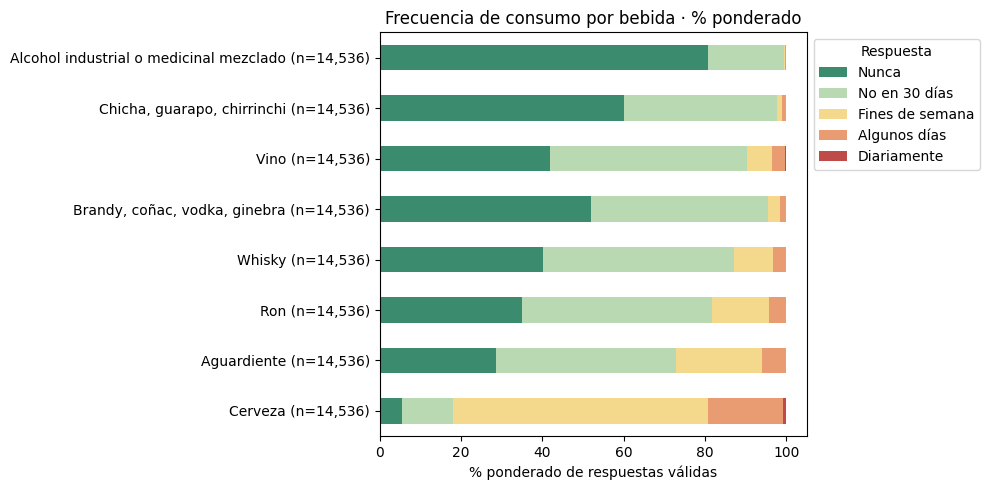

In [10]:
matriz = []
n_bebida = []
for variable in df.filter(regex='^F_10_[A-H] ·').columns:
    sub = df.loc[df['F_07 · Consumo en últimos 30 días'].eq(1)
        & df[variable].isin([1,2,3,4,5])]
    matriz.append(pct_ponderado(sub, variable)['pct_ponderado'].reindex([5,4,2,3,1]).to_numpy())
    n_bebida.append(len(sub))
matriz = pd.DataFrame(matriz, index=[v.split(' · ')[1] for v in df.filter(regex='^F_10_[A-H] ·').columns],
    columns=['Nunca', 'No en 30 días', 'Fines de semana', 'Algunos días', 'Diariamente'])
ax = matriz.plot(kind='barh', stacked=True, color=['#3b8c6e','#b8d9b1','#f4d98c','#e99b72','#be4b48'],
    figsize=(10,5), title='Frecuencia de consumo por bebida · % ponderado')
ax.set_yticklabels([f'{bebida} (n={cantidad:,})' for bebida,cantidad in zip(matriz.index,n_bebida)])
ax.set(xlabel='% ponderado de respuestas válidas', ylabel='')
ax.legend(title='Respuesta', loc='upper left', bbox_to_anchor=(1,1))
ax.figure.tight_layout()
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** La cerveza presenta el mayor consumo reciente entre estas bebidas; aguardiente
y ron también tienen presencia, pero más respuestas de ausencia de consumo reciente.
Las barras muestran la distribución de frecuencia, no volúmenes de alcohol:
beber distintos productos no permite comparar gramos de alcohol sin información adicional.

### F_11–F_14 · Vía, frecuencia, cantidad y consumo fuerte
Base: consumo en 12 meses. F_13 contiene intervalos de tragos, no cantidades
exactas. F_14 entre 3 y 5 identifica seis o más tragos en un día **al menos mensualmente**.

In [11]:
sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
sub['F_11 · Consumo por vía distinta a la oral'] = sub['F_11 · Consumo por vía distinta a la oral'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'F_11 · Consumo por vía distinta a la oral')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_11 · Consumo por vía distinta a la oral,,,
No,99.8,99.8,"26,172"
Sí,0.2,0.2,63


**Interpretación.** La vía distinta a la oral aparece en 63 respuestas, aproximadamente 0.24% ponderado
de los casos válidos. Es una conducta poco frecuente en esta base; su baja proporción
limita los desgloses detallados, aunque no implica que sus consecuencias sean menores.

In [12]:
sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
sub['F_12 · Frecuencia de consumo en 12 meses'] = sub['F_12 · Frecuencia de consumo en 12 meses'].map({1: 'Una vez al mes', 2: '2 a 4 veces al mes', 3: '2 a 3 veces por semana', 4: '4 o más veces por semana'})
tabla = pct_ponderado(sub, 'F_12 · Frecuencia de consumo en 12 meses')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_12 · Frecuencia de consumo en 12 meses,,,
2 a 3 veces por semana,1.8,1.7,470
2 a 4 veces al mes,27.0,26.6,"7,119"
4 o más veces por semana,0.8,0.7,199
Una vez al mes,70.5,71.0,"18,575"


**Interpretación.** En F_12, 71.0% ponderado se ubica en una vez al mes y 26.6% en dos a cuatro veces
al mes. Consumir pocas veces no descarta episodios intensos: la cantidad de F_13
y los seis o más tragos de F_14 aportan información distinta.

In [13]:
sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
sub['F_13 · Tragos en un día habitual (categoría)'] = sub['F_13 · Tragos en un día habitual (categoría)'].map({1: '1 o 2', 2: '3 o 4', 3: '5 o 6', 4: '7, 8 o 9', 5: '10 o más'})
tabla = pct_ponderado(sub, 'F_13 · Tragos en un día habitual (categoría)')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_13 · Tragos en un día habitual (categoría),,,
1 o 2,31.6,33.9,"8,324"
10 o más,13.3,11.4,"3,515"
3 o 4,31.2,30.6,"8,221"
5 o 6,16.4,16.5,"4,325"
"7, 8 o 9",7.5,7.5,"1,978"


**Interpretación.** El 33.9% ponderado reporta 1–2 tragos y 30.6%, 3–4; el 11.4% reporta 10 o más.
La categoría superior muestra una minoría con cantidades altas por ocasión.
Son intervalos: no corresponde promediar los códigos 1–5 como si fueran tragos.

In [14]:
sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
sub['F_14 · Seis o más tragos en un día'] = sub['F_14 · Seis o más tragos en un día'].map({1: 'Nunca', 2: 'Menos de una vez al mes', 3: 'Mensualmente', 4: 'Semanalmente', 5: 'A diario o casi a diario'})
tabla = pct_ponderado(sub, 'F_14 · Seis o más tragos en un día')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_14 · Seis o más tragos en un día,,,
A diario o casi a diario,0.2,0.1,49
Menos de una vez al mes,28.6,28.9,"7,554"
Mensualmente,11.7,10.6,"3,084"
Nunca,55.6,56.6,"14,665"
Semanalmente,3.8,3.7,"1,011"


**Interpretación.** El 56.6% ponderado nunca reporta seis o más tragos en un día y 28.9% lo hace
menos de una vez al mes. Mensual, semanal y diario suman aproximadamente 14.4%.
Esa suma define el binge mensual usado en H1 y en el heatmap; no es un diagnóstico.

### F_15–F_19 · Síntomas y consecuencias
Base confirmada por el manual (p. 47): consumo en 12 meses y F_14 entre 2 y 5.
No se imputa ausencia de síntomas a quienes no respondieron. Los ítems por sí
solos no diagnostican dependencia.

In [15]:
for variable in ['F_15 · Imposibilidad de parar de beber', 'F_16 · Incumplimiento de actividades por beber', 'F_17 · Necesidad de beber en ayunas', 'F_18 · Culpa o remordimientos', 'F_19 · No recordar la noche anterior']:
    sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)
        & df['F_14 · Seis o más tragos en un día'].isin([2, 3, 4, 5])].copy()
    sub[variable] = sub[variable].map({1: 'Nunca', 2: 'Menos de una vez al mes', 3: 'Mensualmente', 4: 'Semanalmente', 5: 'A diario o casi a diario'})
    tabla = pct_ponderado(sub, variable)
    display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_15 · Imposibilidad de parar de beber,,,
A diario o casi a diario,0.5,0.4,61
Menos de una vez al mes,7.7,7.1,903
Mensualmente,2.7,2.3,321
Nunca,87.8,89.2,"10,269"
Semanalmente,1.2,1.1,144


,pct_muestral,pct_ponderado,n_valido
F_16 · Incumplimiento de actividades por beber,,,
A diario o casi a diario,0.2,0.2,22
Menos de una vez al mes,8.2,7.8,958
Mensualmente,1.5,1.3,171
Nunca,89.4,90.0,"10,459"
Semanalmente,0.8,0.6,88


,pct_muestral,pct_ponderado,n_valido
F_17 · Necesidad de beber en ayunas,,,
A diario o casi a diario,0.1,0.1,13
Menos de una vez al mes,3.7,3.8,435
Mensualmente,0.9,0.7,111
Nunca,94.6,94.9,"11,071"
Semanalmente,0.6,0.5,68


,pct_muestral,pct_ponderado,n_valido
F_18 · Culpa o remordimientos,,,
A diario o casi a diario,0.5,0.5,55
Menos de una vez al mes,10.4,10.0,"1,217"
Mensualmente,2.5,2.4,297
Nunca,85.6,86.2,"10,010"
Semanalmente,1.0,0.9,119


,pct_muestral,pct_ponderado,n_valido
F_19 · No recordar la noche anterior,,,
A diario o casi a diario,0.2,0.2,21
Menos de una vez al mes,10.2,9.6,"1,199"
Mensualmente,1.8,1.7,208
Nunca,87.2,88.0,"10,206"
Semanalmente,0.6,0.6,64


**Interpretación.** Nunca predomina en los cinco ítems: 89.2% en pérdida de control, 90.0% en
incumplimiento y 94.9% en ayunas; culpa y pérdida de memoria también son minoritarias.
Se trata exclusivamente de quienes superan el filtro F_14 = 2–5. Estas proporciones
no deben extenderse a todos los consumidores ni interpretarse como diagnósticos.

### F_20–F_21 · Base resuelta con el manual

El [manual DANE, p. 46](../docs/Manual_ENCSPA_2019_recoleccion_VF.pdf#page=46)
indica verificar F_06 antes de F_12–F_21 y aplicar estas preguntas solo si F_06 = Sí.
La p. 47 establece que F_14 = Nunca salta a F_20; la p. 48 define los eventos y su recencia.

**Decisión:** F_20/F_21 describen antecedentes entre consumidores de los últimos
12 meses, no prevalencia de vida entre todos los entrevistados. La recencia del
evento es distinta de la base de aplicación. Se mantienen los filtros F_06 = 1
y, para las subpreguntas, F_20/F_21 = 1. No se convierten saltos en No.
[Cuestionario, sección F](../docs/Cuestionario_ENCSPA_2019.pdf) confirma ese flujo.
F_20 registra lesiones, no consecuencias legales.

In [16]:
sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
sub['F_20 · Lesiones propias o a terceros'] = sub['F_20 · Lesiones propias o a terceros'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'F_20 · Lesiones propias o a terceros')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1) & df['F_20 · Lesiones propias o a terceros'].eq(1)].copy()
sub['F_20_CUAL · Recencia de las lesiones'] = sub['F_20_CUAL · Recencia de las lesiones'].map({1: 'Últimos 12 meses', 2: 'Hace más de 12 meses'})
tabla = pct_ponderado(sub, 'F_20_CUAL · Recencia de las lesiones')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_20 · Lesiones propias o a terceros,,,
No,96.2,96.1,"25,373"
Sí,3.8,3.9,990


,pct_muestral,pct_ponderado,n_valido
F_20_CUAL · Recencia de las lesiones,,,
Hace más de 12 meses,65.5,66.5,648
Últimos 12 meses,34.5,33.5,342


**Interpretación.** El 3.9% ponderado reporta lesiones; entre quienes las reportan, 33.5% las sitúa
en los últimos 12 meses. El evento puede ser antiguo, pero la base sigue siendo
consumidores anuales, como establece el manual. No es prevalencia poblacional de lesiones de vida.

In [17]:
sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
sub['F_21 · Preocupación de otras personas'] = sub['F_21 · Preocupación de otras personas'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'F_21 · Preocupación de otras personas')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1) & df['F_21 · Preocupación de otras personas'].eq(1)].copy()
sub['F_21_CUAL · Recencia de la preocupación'] = sub['F_21_CUAL · Recencia de la preocupación'].map({1: 'Últimos 12 meses', 2: 'Hace más de 12 meses'})
tabla = pct_ponderado(sub, 'F_21_CUAL · Recencia de la preocupación')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_21 · Preocupación de otras personas,,,
No,93.2,93.8,"24,564"
Sí,6.8,6.2,"1,799"


,pct_muestral,pct_ponderado,n_valido
F_21_CUAL · Recencia de la preocupación,,,
Hace más de 12 meses,29.8,27.6,536
Últimos 12 meses,70.2,72.4,"1,263"


**Interpretación.** El 6.3% ponderado reporta preocupación de otras personas, y 72.4% de esos eventos
se ubica en los últimos 12 meses. Este indicador recoge reconocimiento social de
un posible problema, distinto de las lesiones y de la frecuencia de consumo.

### Percepción de riesgo · sección D del alcance original
Todos: D_11_B y D_12_A. Gravedad D_12_A_A solo si D_12_A = Sí.
“No sabe qué riesgo corre” se conserva como respuesta; 9 en gravedad se excluye.

In [18]:
sub = df.loc[df.index.notna()].copy()
sub['D_11_B · Riesgo del consumo frecuente'] = sub['D_11_B · Riesgo del consumo frecuente'].map({1: 'Ningún riesgo', 2: 'Riesgo leve', 3: 'Riesgo moderado', 4: 'Gran riesgo', 5: 'No sabe'})
tabla = pct_ponderado(sub, 'D_11_B · Riesgo del consumo frecuente')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))
sub = df.loc[df.index.notna()].copy()
sub['D_12_A · Alcohol como problema del barrio'] = sub['D_12_A · Alcohol como problema del barrio'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'D_12_A · Alcohol como problema del barrio')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))
sub = df.loc[df['D_12_A · Alcohol como problema del barrio'].eq(1)].copy()
sub['D_12_A_A · Gravedad del problema'] = sub['D_12_A_A · Gravedad del problema'].map({1: 'Grave', 2: 'Leve'})
tabla = pct_ponderado(sub, 'D_12_A_A · Gravedad del problema')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
D_11_B · Riesgo del consumo frecuente,,,
Gran riesgo,83.9,82.2,"41,730"
Ningún riesgo,0.4,0.5,200
No sabe,2.0,1.8,995
Riesgo leve,3.1,3.4,"1,552"
Riesgo moderado,10.6,12.2,"5,279"


,pct_muestral,pct_ponderado,n_valido
D_12_A · Alcohol como problema del barrio,,,
No,35.2,30.2,"17,518"
Sí,64.8,69.8,"32,238"


,pct_muestral,pct_ponderado,n_valido
D_12_A_A · Gravedad del problema,,,
Grave,72.2,71.2,"22,876"
Leve,27.8,28.8,"8,822"


**Interpretación.** El 82.3% ponderado percibe gran riesgo en el consumo frecuente; 69.8% considera
el alcohol un problema del barrio. Entre quienes identifican el problema y responden,
71.2% lo considera grave. Alta percepción de riesgo puede coexistir con consumo:
estas tablas no vinculan todavía ambas respuestas persona a persona.

### Trabajo y embarazo · sección E del alcance original

Son los capítulos R y S del cuestionario (el capítulo E del DANE corresponde a tabaco).
Manual, pp. 64–66: trabajo requiere D_02 = 1; R_02 requiere accidente y R_04
ausencia >0. R_08_B requiere además F_06 = 1. R_02, R_04 y R_09 incluyen alcohol
**u otras sustancias**, no permiten atribución exclusiva al alcohol. Códigos 3/9
no se incluyen como Sí/No.

Embarazo: mujeres que están o han estado embarazadas; frecuencia solo si reportan
alcohol durante embarazo. No equivale al consumo en el embarazo actual.

In [19]:
sub = df.loc[df['D_02 · Actividad principal'].eq(1) & df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
sub['R_08_B · Alcohol en horario laboral'] = sub['R_08_B · Alcohol en horario laboral'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'R_08_B · Alcohol en horario laboral')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))
sub = df.loc[df['D_02 · Actividad principal'].eq(1) & df['R_01 · Accidente laboral'].eq(1)].copy()
sub['R_02 · Sustancias antes del accidente'] = sub['R_02 · Sustancias antes del accidente'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'R_02 · Sustancias antes del accidente')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))
sub = df.loc[df['D_02 · Actividad principal'].eq(1) & df['R_03 · Días de ausencia'].gt(0)].copy()
sub['R_04 · Ausencia por alcohol u otras sustancias'] = sub['R_04 · Ausencia por alcohol u otras sustancias'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'R_04 · Ausencia por alcohol u otras sustancias')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))
sub = df.loc[df['D_02 · Actividad principal'].eq(1)].copy()
sub['R_09 · Menor rendimiento por sustancias'] = sub['R_09 · Menor rendimiento por sustancias'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'R_09 · Menor rendimiento por sustancias')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
R_08_B · Alcohol en horario laboral,,,
No,95.4,95.3,"16,540"
Sí,4.6,4.7,801


,pct_muestral,pct_ponderado,n_valido
R_02 · Sustancias antes del accidente,,,
No,95.3,95.1,973
Sí,4.7,4.9,48


,pct_muestral,pct_ponderado,n_valido
R_04 · Ausencia por alcohol u otras sustancias,,,
No,95.8,96.1,"2,534"
Sí,4.2,3.9,110


,pct_muestral,pct_ponderado,n_valido
R_09 · Menor rendimiento por sustancias,,,
No,98.3,98.5,"27,194"
Sí,1.7,1.6,478


**Interpretación.** El 4.7% ponderado de trabajadores consumidores anuales reporta alcohol en horario laboral.
Las cifras de sustancias antes de accidentes (4.9%), ausencia (3.9%) y rendimiento
(1.6%) usan bases diferentes; no permiten ordenar la frecuencia de consecuencias.
Además, esos últimos ítems incluyen sustancias distintas del alcohol.

In [20]:
sub = df.loc[df['Sexo'].eq('Mujer') & df['S_01 · Ha estado embarazada'].eq(1)].copy()
sub['S_02_B · Alcohol durante embarazo'] = sub['S_02_B · Alcohol durante embarazo'].map({1: 'Sí', 2: 'No'})
tabla = pct_ponderado(sub, 'S_02_B · Alcohol durante embarazo')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))
sub = df.loc[df['Sexo'].eq('Mujer') & df['S_01 · Ha estado embarazada'].eq(1) & df['S_02_B · Alcohol durante embarazo'].eq(1)].copy()
sub['S_02_B_01 · Frecuencia durante embarazo'] = sub['S_02_B_01 · Frecuencia durante embarazo'].map({1: 'Al menos semanal', 2: 'Al menos mensual', 3: 'Al menos una vez en embarazo'})
tabla = pct_ponderado(sub, 'S_02_B_01 · Frecuencia durante embarazo')
display((tabla.round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
S_02_B · Alcohol durante embarazo,,,
No,94.7,95.1,"20,122"
Sí,5.3,4.9,"1,136"


,pct_muestral,pct_ponderado,n_valido
S_02_B_01 · Frecuencia durante embarazo,,,
Al menos mensual,25.0,22.9,284
Al menos semanal,10.7,12.3,122
Al menos una vez en embarazo,64.3,64.8,730


**Interpretación.** El 4.9% ponderado reporta consumo durante algún embarazo entre mujeres elegibles.
Entre quienes lo reportan, 64.8% se clasifica como al menos una vez, 22.9% mensual
y 12.3% semanal. No se identifica necesariamente el embarazo actual ni la edad
durante ese episodio; la lectura es retrospectiva.

## Resultados analíticos

> **ADVERTENCIA METODOLÓGICA:** los p-valores usan chi-cuadrado estándar de SciPy
> (Yates en 2×2; Fisher si procede), sobre conteos **sin ponderar**. No incorporan
> el diseño complejo del DANE. Ignorar conglomeración y estratificación puede
> subestimar la incertidumbre e inflar la significancia; su magnitud no se ha
> estimado aquí. **Todos estos resultados son exploratorios.**
>
> Para la versión inferencial se recomienda **chi-cuadrado de Rao–Scott**:
> [survey::svychisq en R](https://r-survey.r-forge.r-project.org/survey/html/svychisq.html)
> o tabulación de encuestas con [samplics en Python](https://samplics-org.github.io/samplics/pages/categorical_tabulation.html).
> Se necesitan identificadores de estratos/conglomerados o pesos replicados:
> FEX_C por sí solo no basta. El estrato socioeconómico no sustituye al estrato de muestreo.

Los gráficos usan porcentajes ponderados dentro de cada grupo; las tablas
permiten comparar con la muestra. En 2×2 se aplica Yates, o Fisher si alguna
esperada es <5. En tablas mayores se omite el p si más del 20% de esperadas
son <5 o alguna es <1. V de Cramér usa Pearson sin corrección como medida
descriptiva. No se ajusta por comparaciones múltiples.



In [21]:
binge = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)
    & df['F_14 · Seis o más tragos en un día'].isin([1, 2, 3, 4, 5])].copy()
binge['Binge mensual'] = binge['F_14 · Seis o más tragos en un día'].ge(3).map({True: 'Sí', False: 'No'})

### Resultado central · binge por edad y sexo
Prevalencia de binge al menos mensual entre consumidores anuales con F_14 válido.
Cada casilla muestra porcentaje ponderado y n válido de su combinación.
La diferencia hombre–mujer se calcula en puntos porcentuales; no es una prueba
de interacción ni demuestra que las diferencias entre edades sean significativas.

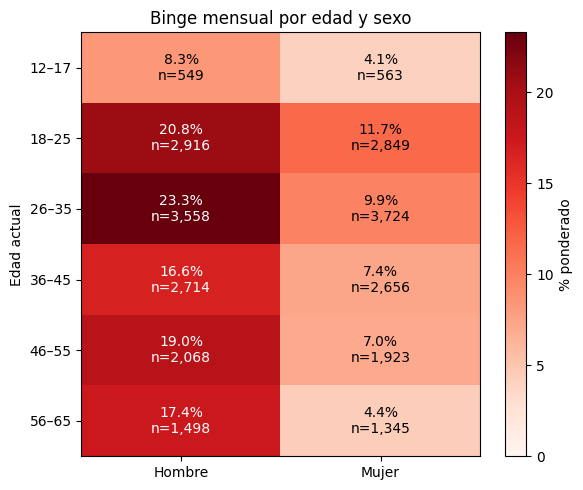

,Brecha hombre–mujer (pp)
grupo_edad,
12–17,4.2
18–25,9.1
26–35,13.4
36–45,9.2
46–55,12.0
56–65,13.0


Mayor brecha observada: 26–35 (13.4 pp); menor: 12–17 (4.2 pp). Se describen grupos de edad, no edades exactas ni efectos ajustados.


In [22]:
sub = binge.dropna(subset=['grupo_edad', 'Sexo']).copy()
sub['peso_binge'] = sub.fex_c * sub['Binge mensual'].eq('Sí')
cruce = sub.groupby(['grupo_edad','Sexo'], observed=True)[['peso_binge','fex_c']].sum()
cruce['% binge'] = 100*cruce.peso_binge/cruce.fex_c
cruce['n válido'] = sub.groupby(['grupo_edad','Sexo'], observed=True).size()
mapa = cruce['% binge'].unstack('Sexo').reindex(columns=['Hombre','Mujer'])
conteos_mapa = cruce['n válido'].unstack('Sexo').reindex(columns=mapa.columns)
fig, ax = plt.subplots(figsize=(6,5))
imagen = ax.imshow(mapa, cmap='Reds', vmin=0, vmax=mapa.max().max(), aspect='auto')
ax.set_xticks(range(len(mapa.columns)), mapa.columns)
ax.set_yticks(range(len(mapa.index)), mapa.index)
for i in range(len(mapa.index)):
    for j in range(len(mapa.columns)):
        valor = mapa.iloc[i,j]
        ax.text(j,i,f'{valor:.1f}%\nn={conteos_mapa.iloc[i,j]:,}', ha='center', va='center',
            color='white' if valor > mapa.max().max()*.6 else 'black')
fig.colorbar(imagen, ax=ax, label='% ponderado')
ax.set(title='Binge mensual por edad y sexo', ylabel='Edad actual')
fig.tight_layout()
display(fig)
plt.close(fig)
brecha = (mapa['Hombre']-mapa['Mujer']).rename('Brecha hombre–mujer (pp)')
display((brecha.to_frame().round(2)).style.format(precision=1, thousands=',', na_rep='—'))
print(f'Mayor brecha observada: {brecha.idxmax()} ({brecha.max():.1f} pp); '
      f'menor: {brecha.idxmin()} ({brecha.min():.1f} pp). '
      'Se describen grupos de edad, no edades exactas ni efectos ajustados.')

**Interpretación.** El binge es mayor en hombres en todos los grupos: alcanza 20.8% a los 18–25 años
y 23.3% a los 26–35, frente a un máximo femenino de 11.7% a los 18–25.
La mayor brecha es 26–35 (13.4 puntos), y la menor 12–17 (4.2).
Es un patrón para investigar prioridades preventivas.

,n_valido
grupo_edad,
12–17,"1,112"
18–25,"5,765"
26–35,"7,282"
36–45,"5,370"
46–55,"3,991"
56–65,"2,843"


χ²=134.45, gl=5, p=2.7e-27; Yates=False
V de Cramér (Pearson)=0.071; esperadas <5: 0.0%; mínima=174.80
Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.


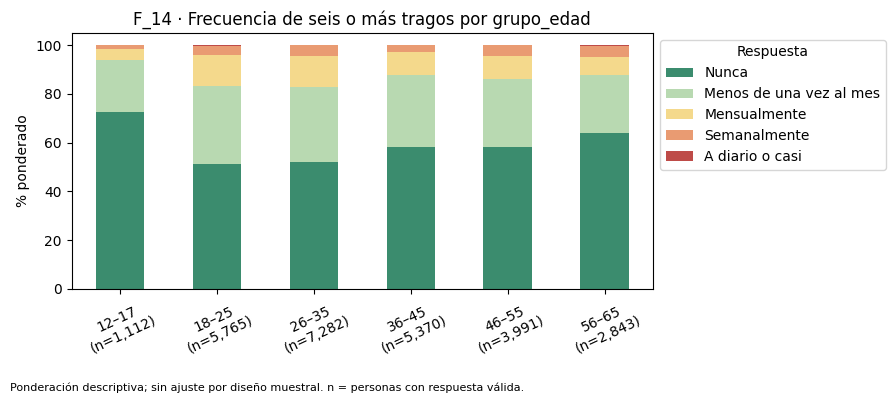

In [23]:
sub = binge.dropna(subset=['Binge mensual', 'grupo_edad', 'fex_c']).copy()
conteos = pd.crosstab(sub['Binge mensual'], sub['grupo_edad'])
ponderada = pd.crosstab(sub['Binge mensual'], sub['grupo_edad'], values=sub.fex_c,
    aggfunc='sum', normalize='columns') * 100
muestral = pd.crosstab(sub['Binge mensual'], sub['grupo_edad'], normalize='columns') * 100
display((pd.concat([ponderada, muestral], keys=['% ponderado', '% muestral']).round(2)).style.format(precision=1, thousands=',', na_rep='—'))
n_grupo = conteos.sum().rename('n_valido').to_frame()
display((n_grupo).style.format(precision=1, thousands=',', na_rep='—'))
chi2_pearson, _, _, esperadas = chi2_contingency(conteos, correction=False)
v_cramer = np.sqrt(chi2_pearson / (conteos.to_numpy().sum() * min(conteos.shape[0]-1, conteos.shape[1]-1)))
if conteos.shape == (2, 2) and (esperadas < 5).any():
    _, p = fisher_exact(conteos)
    print(f'Fisher exacto: p={p:.3g}')
elif esperadas.min() >= 1 and (esperadas < 5).mean() <= .20:
    chi2, p, gl, _ = chi2_contingency(conteos, correction=conteos.shape == (2, 2))
    print(f'χ²={chi2:.2f}, gl={gl}, p={p:.3g}; Yates={conteos.shape == (2, 2)}')
else:
    print('No se informa p: frecuencias esperadas insuficientes para chi-cuadrado.')
print(f'V de Cramér (Pearson)={v_cramer:.3f}; esperadas <5: {(esperadas < 5).mean():.1%}; mínima={esperadas.min():.2f}')
print('Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.')
binge_edad = ponderada.loc['Sí'].to_frame('% ponderado').join(n_grupo)
# Distribución completa de F_14, además del indicador binario.
sub['Frecuencia F_14'] = sub['F_14 · Seis o más tragos en un día'].map({1:'Nunca',2:'Menos de una vez al mes',
    3:'Mensualmente',4:'Semanalmente',5:'A diario o casi'})
distribucion = pd.crosstab(sub['Frecuencia F_14'], sub['grupo_edad'], values=sub.fex_c,
    aggfunc='sum', normalize='columns').reindex(['Nunca','Menos de una vez al mes','Mensualmente','Semanalmente','A diario o casi']) * 100
ax = distribucion.T.plot(kind='bar', stacked=True, color=['#3b8c6e','#b8d9b1','#f4d98c','#e99b72','#be4b48'], figsize=(9,4), rot=25)
ax.set(title='F_14 · Frecuencia de seis o más tragos por grupo_edad', ylabel='% ponderado', xlabel='')
ax.set_xticklabels([f'{g}\n(n={int(n_grupo.loc[g, "n_valido"]):,})' for g in n_grupo.index])
ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Respuesta')
ax.figure.text(.01, .01, 'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.', fontsize=8)
ax.figure.tight_layout(rect=(0,.06,1,1))
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** El binge mensual varía aproximadamente de 6.2% a 17.4% entre grupos de edad
y alcanza el máximo en 26–35. La asociación muestral es pequeña (V≈0.071),
aunque el p simple sea muy bajo. Rao–Scott puede modificar esa inferencia;
la mezcla de sexos dentro de cada grupo ayuda a entender el contraste con el heatmap.

,n_valido
Sexo,
Hombre,"13,303"
Mujer,"13,060"


χ²=706.53, gl=1, p=1.14e-155; Yates=True
V de Cramér (Pearson)=0.164; esperadas <5: 0.0%; mínima=2052.90
Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.


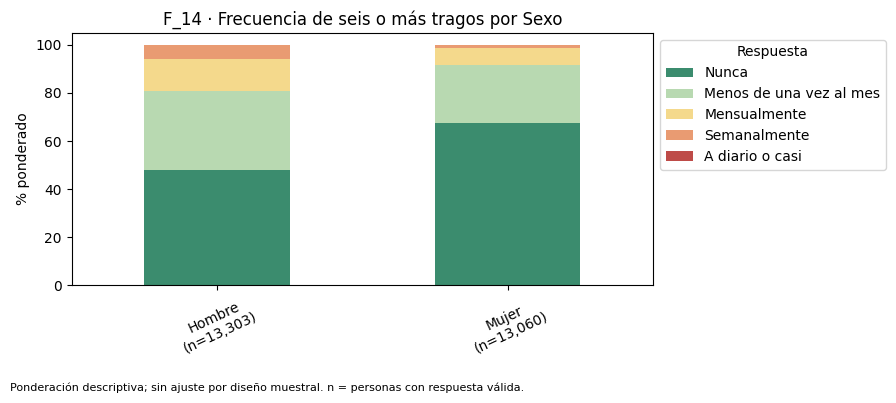

In [24]:
sub = binge.dropna(subset=['Binge mensual', 'Sexo', 'fex_c']).copy()
conteos = pd.crosstab(sub['Binge mensual'], sub['Sexo'])
ponderada = pd.crosstab(sub['Binge mensual'], sub['Sexo'], values=sub.fex_c,
    aggfunc='sum', normalize='columns') * 100
muestral = pd.crosstab(sub['Binge mensual'], sub['Sexo'], normalize='columns') * 100
display((pd.concat([ponderada, muestral], keys=['% ponderado', '% muestral']).round(2)).style.format(precision=1, thousands=',', na_rep='—'))
n_grupo = conteos.sum().rename('n_valido').to_frame()
display((n_grupo).style.format(precision=1, thousands=',', na_rep='—'))
chi2_pearson, _, _, esperadas = chi2_contingency(conteos, correction=False)
v_cramer = np.sqrt(chi2_pearson / (conteos.to_numpy().sum() * min(conteos.shape[0]-1, conteos.shape[1]-1)))
if conteos.shape == (2, 2) and (esperadas < 5).any():
    _, p = fisher_exact(conteos)
    print(f'Fisher exacto: p={p:.3g}')
elif esperadas.min() >= 1 and (esperadas < 5).mean() <= .20:
    chi2, p, gl, _ = chi2_contingency(conteos, correction=conteos.shape == (2, 2))
    print(f'χ²={chi2:.2f}, gl={gl}, p={p:.3g}; Yates={conteos.shape == (2, 2)}')
else:
    print('No se informa p: frecuencias esperadas insuficientes para chi-cuadrado.')
print(f'V de Cramér (Pearson)={v_cramer:.3f}; esperadas <5: {(esperadas < 5).mean():.1%}; mínima={esperadas.min():.2f}')
print('Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.')
binge_sexo = ponderada.loc['Sí'].to_frame('% ponderado').join(n_grupo)
# Distribución completa de F_14, además del indicador binario.
sub['Frecuencia F_14'] = sub['F_14 · Seis o más tragos en un día'].map({1:'Nunca',2:'Menos de una vez al mes',
    3:'Mensualmente',4:'Semanalmente',5:'A diario o casi'})
distribucion = pd.crosstab(sub['Frecuencia F_14'], sub['Sexo'], values=sub.fex_c,
    aggfunc='sum', normalize='columns').reindex(['Nunca','Menos de una vez al mes','Mensualmente','Semanalmente','A diario o casi']) * 100
ax = distribucion.T.plot(kind='bar', stacked=True, color=['#3b8c6e','#b8d9b1','#f4d98c','#e99b72','#be4b48'], figsize=(9,4), rot=25)
ax.set(title='F_14 · Frecuencia de seis o más tragos por Sexo', ylabel='% ponderado', xlabel='')
ax.set_xticklabels([f'{g}\n(n={int(n_grupo.loc[g, "n_valido"]):,})' for g in n_grupo.index])
ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Respuesta')
ax.figure.text(.01, .01, 'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.', fontsize=8)
ax.figure.tight_layout(rect=(0,.06,1,1))
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** El binge mensual es 19.19% ponderado en hombres frente a 8.41% en mujeres:
una diferencia de 10.78 puntos porcentuales, coherente con H1.
V≈0.164 indica una asociación muestral débil; un p pequeño no la convierte en fuerte.
La prueba no está ajustada por diseño ni por otras variables.

,n_valido
Educación,
Ninguno / preescolar,203
Primaria,"2,499"
Secundaria,"3,421"
Media,"8,108"
Técnica/tecnológica,"5,241"
Universitaria,"5,442"
Postgrado,"1,439"


χ²=54.44, gl=6, p=6.02e-10; Yates=False
V de Cramér (Pearson)=0.045; esperadas <5: 0.0%; mínima=31.91
Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.


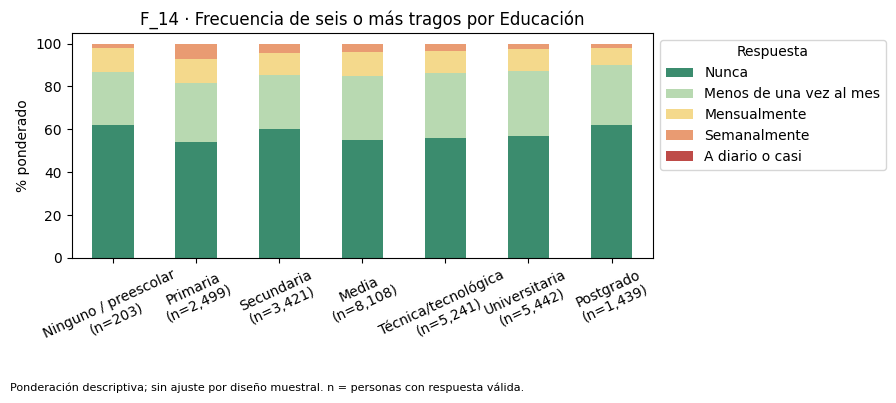

In [25]:
sub = binge.dropna(subset=['Binge mensual', 'Educación', 'fex_c']).copy()
conteos = pd.crosstab(sub['Binge mensual'], sub['Educación'])
ponderada = pd.crosstab(sub['Binge mensual'], sub['Educación'], values=sub.fex_c,
    aggfunc='sum', normalize='columns') * 100
muestral = pd.crosstab(sub['Binge mensual'], sub['Educación'], normalize='columns') * 100
display((pd.concat([ponderada, muestral], keys=['% ponderado', '% muestral']).round(2)).style.format(precision=1, thousands=',', na_rep='—'))
n_grupo = conteos.sum().rename('n_valido').to_frame()
display((n_grupo).style.format(precision=1, thousands=',', na_rep='—'))
chi2_pearson, _, _, esperadas = chi2_contingency(conteos, correction=False)
v_cramer = np.sqrt(chi2_pearson / (conteos.to_numpy().sum() * min(conteos.shape[0]-1, conteos.shape[1]-1)))
if conteos.shape == (2, 2) and (esperadas < 5).any():
    _, p = fisher_exact(conteos)
    print(f'Fisher exacto: p={p:.3g}')
elif esperadas.min() >= 1 and (esperadas < 5).mean() <= .20:
    chi2, p, gl, _ = chi2_contingency(conteos, correction=conteos.shape == (2, 2))
    print(f'χ²={chi2:.2f}, gl={gl}, p={p:.3g}; Yates={conteos.shape == (2, 2)}')
else:
    print('No se informa p: frecuencias esperadas insuficientes para chi-cuadrado.')
print(f'V de Cramér (Pearson)={v_cramer:.3f}; esperadas <5: {(esperadas < 5).mean():.1%}; mínima={esperadas.min():.2f}')
print('Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.')
binge_educacion = ponderada.loc['Sí'].to_frame('% ponderado').join(n_grupo)
# Distribución completa de F_14, además del indicador binario.
sub['Frecuencia F_14'] = sub['F_14 · Seis o más tragos en un día'].map({1:'Nunca',2:'Menos de una vez al mes',
    3:'Mensualmente',4:'Semanalmente',5:'A diario o casi'})
distribucion = pd.crosstab(sub['Frecuencia F_14'], sub['Educación'], values=sub.fex_c,
    aggfunc='sum', normalize='columns').reindex(['Nunca','Menos de una vez al mes','Mensualmente','Semanalmente','A diario o casi']) * 100
ax = distribucion.T.plot(kind='bar', stacked=True, color=['#3b8c6e','#b8d9b1','#f4d98c','#e99b72','#be4b48'], figsize=(9,4), rot=25)
ax.set(title='F_14 · Frecuencia de seis o más tragos por Educación', ylabel='% ponderado', xlabel='')
ax.set_xticklabels([f'{g}\n(n={int(n_grupo.loc[g, "n_valido"]):,})' for g in n_grupo.index])
ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Respuesta')
ax.figure.text(.01, .01, 'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.', fontsize=8)
ax.figure.tight_layout(rect=(0,.06,1,1))
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** Primaria presenta la mayor proporción observada de binge mensual (18.5%);
los grupos educativos oscilan aproximadamente entre 10.0% y 18.5%.
V≈0.045 señala una asociación pequeña. La edad y el sexo pueden explicar parte
del patrón; el cruce no demuestra un efecto independiente de la educación.

### F_04 · Edad de inicio × sexo y edad actual
Base: consumo alguna vez e inicio válido. Descriptivos sin ponderar y medias ponderadas en años. La distribución por sexo se muestra con boxplots. Diferencias
por edad actual también pueden reflejar cohortes, recuerdo y tiempo disponible
para iniciar consumo.
El boxplot es muestral (mediana, cuartiles, bigotes de 1,5 IQR); los puntos extremos se conservan.

,count,mean,std,min,25%,50%,75%,max
grupo_edad,,,,,,,,
12–17,"1,642",13.8,2.0,3.0,13.0,14.0,15.0,17.0
18–25,"7,786",16.4,2.3,1.0,15.0,17.0,18.0,25.0
26–35,"10,400",17.4,3.1,1.0,15.0,17.0,19.0,34.0
36–45,"8,364",18.3,4.1,1.0,16.0,18.0,20.0,44.0
46–55,"7,347",19.6,5.6,3.0,17.0,18.0,20.0,54.0
56–65,"6,902",20.4,6.5,1.0,17.0,19.0,22.0,61.0


,count,mean,std,min,25%,50%,75%,max
Sexo,,,,,,,,
Hombre,"18,612",16.9,3.5,1.0,15.0,17.0,18.0,59.0
Mujer,"23,829",19.1,5.2,1.0,16.0,18.0,20.0,61.0


,Edad media ponderada,n_valido
Sexo,,
Hombre,16.8,"18,612"
Mujer,18.7,"23,829"


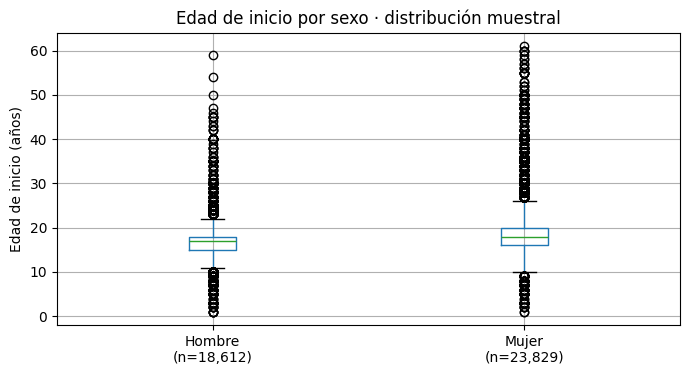

In [26]:
display((inicio.groupby('grupo_edad', observed=True)['F_04 · Edad de inicio del consumo'].describe()).style.format(precision=1, thousands=',', na_rep='—').format('{:,.0f}', subset=['count']))
display((inicio.groupby('Sexo')['F_04 · Edad de inicio del consumo'].describe()).style.format(precision=1, thousands=',', na_rep='—').format('{:,.0f}', subset=['count']))
sub = inicio.dropna(subset=['Sexo']).copy()
sub['edad_por_peso'] = sub['F_04 · Edad de inicio del consumo'] * sub.fex_c
inicio_sexo = (sub.groupby('Sexo').edad_por_peso.sum()
    / sub.groupby('Sexo').fex_c.sum()).rename('Edad media ponderada').to_frame()
inicio_sexo['n_valido'] = sub.groupby('Sexo').size()
display((inicio_sexo).style.format(precision=1, thousands=',', na_rep='—'))
ax = inicio.boxplot(column='F_04 · Edad de inicio del consumo', by='Sexo', figsize=(7,4))
n_sexo = inicio.groupby('Sexo').size()
ax.set_xticklabels([f'{g}\n(n={n_sexo[g]:,})' for g in n_sexo.index])
ax.set(title='Edad de inicio por sexo · distribución muestral', xlabel='', ylabel='Edad de inicio (años)')
ax.figure.suptitle('')
ax.figure.tight_layout()
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** Los hombres reportan inicio medio ponderado a los 16.83 años y las mujeres a
los 18.72: casi 1.9 años de diferencia, consistente con H3. El boxplot muestra
mayor dispersión y una cola más larga en mujeres. Los grupos de edad y el recuerdo
pueden influir: falta un contraste de medias con diseño y control de confusión.

### F_17 · Beber en ayunas × edad
Base: F_14 entre 2 y 5, consumo en 12 meses y F_17 válido. Se contrastan las cinco
categorías; el gráfico resume respuestas distintas de “Nunca”. No equivale a
prevalencia de dependencia.
La prueba se realiza sobre Nunca / Alguna frecuencia para resolver la escasez de frecuencias esperadas; la visualización mantiene las cinco categorías.

,n_valido
grupo_edad,
12–17,319
18–25,"2,835"
26–35,"3,484"
36–45,"2,304"
46–55,"1,667"
56–65,"1,089"


Prueba sobre Nunca / Alguna frecuencia:
χ²=14.88, gl=5, p=0.0109; Yates=False
V de Cramér (Pearson)=0.036; esperadas <5: 0.0%; mínima=17.10
Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.


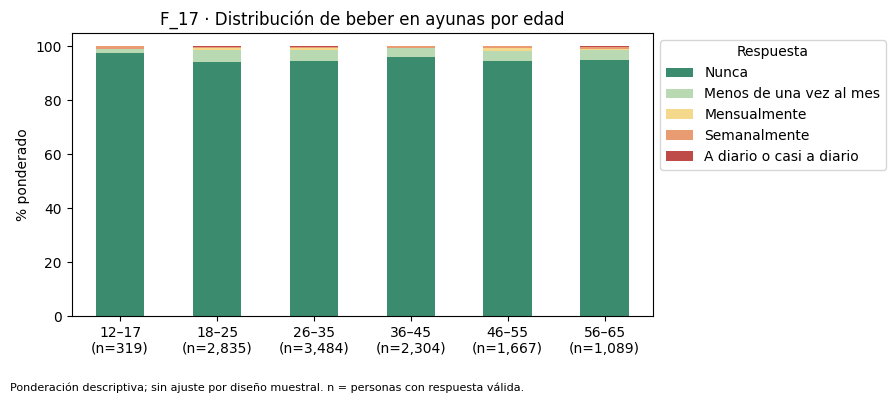

In [27]:
sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1) & df['F_14 · Seis o más tragos en un día'].isin([2, 3, 4, 5])].copy()
sub['F_17 · Necesidad de beber en ayunas'] = sub['F_17 · Necesidad de beber en ayunas'].map({1: 'Nunca', 2: 'Menos de una vez al mes', 3: 'Mensualmente', 4: 'Semanalmente', 5: 'A diario o casi a diario'})

sub = sub.dropna(subset=['F_17 · Necesidad de beber en ayunas', 'grupo_edad', 'fex_c'])
conteos = pd.crosstab(sub['F_17 · Necesidad de beber en ayunas'], sub['grupo_edad'])
ponderada = pd.crosstab(sub['F_17 · Necesidad de beber en ayunas'], sub['grupo_edad'], values=sub.fex_c,
    aggfunc='sum', normalize='columns') * 100
muestral = pd.crosstab(sub['F_17 · Necesidad de beber en ayunas'], sub['grupo_edad'], normalize='columns') * 100
display((pd.concat([ponderada, muestral], keys=['% ponderado', '% muestral']).round(2)).style.format(precision=1, thousands=',', na_rep='—'))
n_grupo = conteos.sum().rename('n_valido').to_frame()
display((n_grupo).style.format(precision=1, thousands=',', na_rep='—'))
# Test binario; la tabla y el gráfico conservan las cinco frecuencias.
sub['Ayunas: alguna frecuencia'] = sub['F_17 · Necesidad de beber en ayunas'].ne('Nunca').map({True:'Alguna frecuencia', False:'Nunca'})
conteos = pd.crosstab(sub['Ayunas: alguna frecuencia'], sub.grupo_edad)
print('Prueba sobre Nunca / Alguna frecuencia:')
chi2_pearson, _, _, esperadas = chi2_contingency(conteos, correction=False)
v_cramer = np.sqrt(chi2_pearson / (conteos.to_numpy().sum() * min(conteos.shape[0]-1, conteos.shape[1]-1)))
if conteos.shape == (2, 2) and (esperadas < 5).any():
    _, p = fisher_exact(conteos)
    print(f'Fisher exacto: p={p:.3g}')
elif esperadas.min() >= 1 and (esperadas < 5).mean() <= .20:
    chi2, p, gl, _ = chi2_contingency(conteos, correction=conteos.shape == (2, 2))
    print(f'χ²={chi2:.2f}, gl={gl}, p={p:.3g}; Yates={conteos.shape == (2, 2)}')
else:
    print('No se informa p: frecuencias esperadas insuficientes para chi-cuadrado.')
print(f'V de Cramér (Pearson)={v_cramer:.3f}; esperadas <5: {(esperadas < 5).mean():.1%}; mínima={esperadas.min():.2f}')
print('Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.')
ayunas_edad = (100 - ponderada.loc['Nunca']).to_frame('% ponderado').join(n_grupo)
distribucion = ponderada.reindex(['Nunca','Menos de una vez al mes','Mensualmente','Semanalmente','A diario o casi a diario'])
ax = distribucion.T.plot(kind='bar', stacked=True, color=['#3b8c6e','#b8d9b1','#f4d98c','#e99b72','#be4b48'], figsize=(9,4), rot=0)
ax.set(title='F_17 · Distribución de beber en ayunas por edad', ylabel='% ponderado', xlabel='')
ax.set_xticklabels([f'{g}\n(n={int(n_grupo.loc[g, "n_valido"]):,})' for g in n_grupo.index])
ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Respuesta')
ax.figure.text(.01, .01, 'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.', fontsize=8)
ax.figure.tight_layout(rect=(0,.06,1,1))
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** La categoría Nunca domina F_17, pero el porcentaje con alguna frecuencia varía
por edad, aproximadamente 2.6–5.9%. Al agrupar Nunca/Alguna frecuencia, las
esperadas son suficientes; V≈0.036 sigue siendo muy pequeño. El p exploratorio
no demuestra una asociación poblacional ajustada ni dependencia clínica.

### F_01 / F_02 · Entorno × consumo en 12 meses
Base: quienes consumieron alguna vez, con F_06 y entorno válidos. Porcentaje de
consumo anual dentro de cada entorno; no se extrapola a quienes nunca consumieron.

,n_valido
F_01 · Familiares que se emborrachan frecuentemente,
No,"27,310"
Sí,"15,079"


χ²=169.59, gl=1, p=9.09e-39; Yates=True
V de Cramér (Pearson)=0.063; esperadas <5: 0.0%; mínima=5700.91
Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.


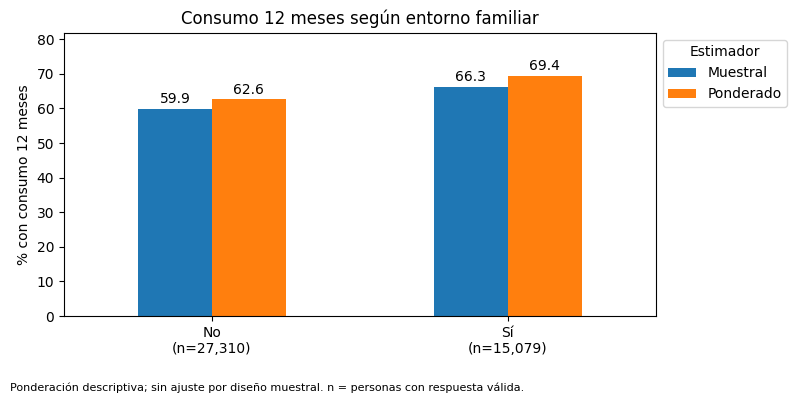

In [28]:
sub = df.loc[df['F_03 · Consumo de alcohol alguna vez'].eq(1)].copy()
sub['F_01 · Familiares que se emborrachan frecuentemente'] = sub['F_01 · Familiares que se emborrachan frecuentemente'].map({1: 'Sí', 2: 'No'})
sub['F_06 · Consumo en últimos 12 meses'] = sub['F_06 · Consumo en últimos 12 meses'].map({1: 'Sí', 2: 'No'})

sub = sub.dropna(subset=['F_06 · Consumo en últimos 12 meses', 'F_01 · Familiares que se emborrachan frecuentemente', 'fex_c'])
conteos = pd.crosstab(sub['F_06 · Consumo en últimos 12 meses'], sub['F_01 · Familiares que se emborrachan frecuentemente'])
ponderada = pd.crosstab(sub['F_06 · Consumo en últimos 12 meses'], sub['F_01 · Familiares que se emborrachan frecuentemente'], values=sub.fex_c,
    aggfunc='sum', normalize='columns') * 100
muestral = pd.crosstab(sub['F_06 · Consumo en últimos 12 meses'], sub['F_01 · Familiares que se emborrachan frecuentemente'], normalize='columns') * 100
display((pd.concat([ponderada, muestral], keys=['% ponderado', '% muestral']).round(2)).style.format(precision=1, thousands=',', na_rep='—'))
n_grupo = conteos.sum().rename('n_valido').to_frame()
display((n_grupo).style.format(precision=1, thousands=',', na_rep='—'))
chi2_pearson, _, _, esperadas = chi2_contingency(conteos, correction=False)
v_cramer = np.sqrt(chi2_pearson / (conteos.to_numpy().sum() * min(conteos.shape[0]-1, conteos.shape[1]-1)))
if conteos.shape == (2, 2) and (esperadas < 5).any():
    _, p = fisher_exact(conteos)
    print(f'Fisher exacto: p={p:.3g}')
elif esperadas.min() >= 1 and (esperadas < 5).mean() <= .20:
    chi2, p, gl, _ = chi2_contingency(conteos, correction=conteos.shape == (2, 2))
    print(f'χ²={chi2:.2f}, gl={gl}, p={p:.3g}; Yates={conteos.shape == (2, 2)}')
else:
    print('No se informa p: frecuencias esperadas insuficientes para chi-cuadrado.')
print(f'V de Cramér (Pearson)={v_cramer:.3f}; esperadas <5: {(esperadas < 5).mean():.1%}; mínima={esperadas.min():.2f}')
print('Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.')
entorno_familiar = ponderada.loc['Sí'].to_frame('% ponderado').join(n_grupo)
comparacion = pd.concat([muestral.loc['Sí'], ponderada.loc['Sí']], axis=1,
    keys=['Muestral', 'Ponderado'])
ax = comparacion.plot(kind='bar', figsize=(8,4), rot=0)
ax.set(title='Consumo 12 meses según entorno familiar', ylabel='% con consumo 12 meses', xlabel='')
for barras in ax.containers:
    ax.bar_label(barras, fmt='%.1f', padding=2)
ax.set_ylim(0, min(100, comparacion.max().max()*1.18))
ax.set_xticklabels([f'{g}\n(n={int(n_grupo.loc[g, "n_valido"]):,})' for g in n_grupo.index])
ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Estimador')
ax.figure.text(.01, .01, 'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.', fontsize=8)
ax.figure.tight_layout(rect=(0,.06,1,1))
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** El consumo anual alcanza 69.4% ponderado con familiares que se emborrachan,
frente a 62.6% sin ese entorno: unos 6.8 puntos de diferencia.
V≈0.063 es pequeño; el gráfico compara estimadores, no dos tipos de respuesta.
La asociación puede reflejar características compartidas y requiere ajuste por diseño.

,n_valido
F_02 · Amigos que se emborrachan frecuentemente,
No,"22,829"
Sí,"19,560"


χ²=1326.36, gl=1, p=2.11e-290; Yates=True
V de Cramér (Pearson)=0.177; esperadas <5: 0.0%; mínima=7395.04
Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.


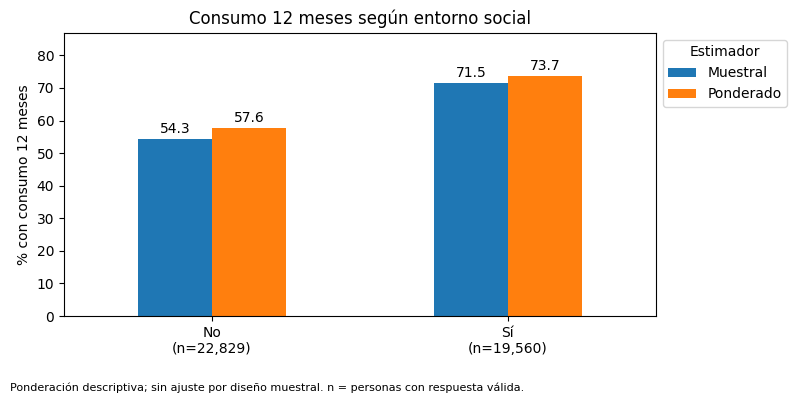

H2: V de Cramér = 0.177; asociación débil. El p-valor es pequeño bajo la prueba simple, pero no demuestra una relación fuerte ni significancia ajustada por diseño. El valor 0.164 corresponde a binge × sexo, no a H2.


In [29]:
sub = df.loc[df['F_03 · Consumo de alcohol alguna vez'].eq(1)].copy()
sub['F_02 · Amigos que se emborrachan frecuentemente'] = sub['F_02 · Amigos que se emborrachan frecuentemente'].map({1: 'Sí', 2: 'No'})
sub['F_06 · Consumo en últimos 12 meses'] = sub['F_06 · Consumo en últimos 12 meses'].map({1: 'Sí', 2: 'No'})

sub = sub.dropna(subset=['F_06 · Consumo en últimos 12 meses', 'F_02 · Amigos que se emborrachan frecuentemente', 'fex_c'])
conteos = pd.crosstab(sub['F_06 · Consumo en últimos 12 meses'], sub['F_02 · Amigos que se emborrachan frecuentemente'])
ponderada = pd.crosstab(sub['F_06 · Consumo en últimos 12 meses'], sub['F_02 · Amigos que se emborrachan frecuentemente'], values=sub.fex_c,
    aggfunc='sum', normalize='columns') * 100
muestral = pd.crosstab(sub['F_06 · Consumo en últimos 12 meses'], sub['F_02 · Amigos que se emborrachan frecuentemente'], normalize='columns') * 100
display((pd.concat([ponderada, muestral], keys=['% ponderado', '% muestral']).round(2)).style.format(precision=1, thousands=',', na_rep='—'))
n_grupo = conteos.sum().rename('n_valido').to_frame()
display((n_grupo).style.format(precision=1, thousands=',', na_rep='—'))
chi2_pearson, _, _, esperadas = chi2_contingency(conteos, correction=False)
v_cramer = np.sqrt(chi2_pearson / (conteos.to_numpy().sum() * min(conteos.shape[0]-1, conteos.shape[1]-1)))
if conteos.shape == (2, 2) and (esperadas < 5).any():
    _, p = fisher_exact(conteos)
    print(f'Fisher exacto: p={p:.3g}')
elif esperadas.min() >= 1 and (esperadas < 5).mean() <= .20:
    chi2, p, gl, _ = chi2_contingency(conteos, correction=conteos.shape == (2, 2))
    print(f'χ²={chi2:.2f}, gl={gl}, p={p:.3g}; Yates={conteos.shape == (2, 2)}')
else:
    print('No se informa p: frecuencias esperadas insuficientes para chi-cuadrado.')
print(f'V de Cramér (Pearson)={v_cramer:.3f}; esperadas <5: {(esperadas < 5).mean():.1%}; mínima={esperadas.min():.2f}')
print('Nota: porcentajes ponderados descriptivos para la cobertura ENCSPA; prueba y V de Cramér sobre conteos SIN ponderar. Sin ajuste por estratos/conglomerados: p exploratorio, puede subestimar la incertidumbre; no es inferencia poblacional.')
entorno_social = ponderada.loc['Sí'].to_frame('% ponderado').join(n_grupo)
comparacion = pd.concat([muestral.loc['Sí'], ponderada.loc['Sí']], axis=1,
    keys=['Muestral', 'Ponderado'])
ax = comparacion.plot(kind='bar', figsize=(8,4), rot=0)
ax.set(title='Consumo 12 meses según entorno social', ylabel='% con consumo 12 meses', xlabel='')
for barras in ax.containers:
    ax.bar_label(barras, fmt='%.1f', padding=2)
ax.set_ylim(0, min(100, comparacion.max().max()*1.18))
ax.set_xticklabels([f'{g}\n(n={int(n_grupo.loc[g, "n_valido"]):,})' for g in n_grupo.index])
ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Estimador')
ax.figure.text(.01, .01, 'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.', fontsize=8)
ax.figure.tight_layout(rect=(0,.06,1,1))
display(ax.figure)
plt.close(ax.figure)
print(f"H2: V de Cramér = {v_cramer:.3f}; asociación débil. "
      "El p-valor es pequeño bajo la prueba simple, pero no demuestra una relación fuerte "
      "ni significancia ajustada por diseño. El valor 0.164 corresponde a binge × sexo, no a H2.")

**Interpretación.** Con amigos que se emborrachan, el consumo anual es 73.66%, frente a 57.64%
sin ese entorno: 16.02 puntos de diferencia, coherente con H2.
V≈0.177 indica asociación débil, aunque el p de la prueba simple sea pequeño.
No prueba influencia causal de los amigos ni significancia ajustada por diseño.

### Frecuencia, cantidad y síntomas × edad
Se muestran distribuciones completas ponderadas de F_12, F_13 y F_15/F_16/F_18/F_19.
F_12/F_13: consumo en 12 meses. Síntomas: además F_14 = 2–5.
Las cifras son descriptivas; no se añaden pruebas múltiples a estos gráficos.

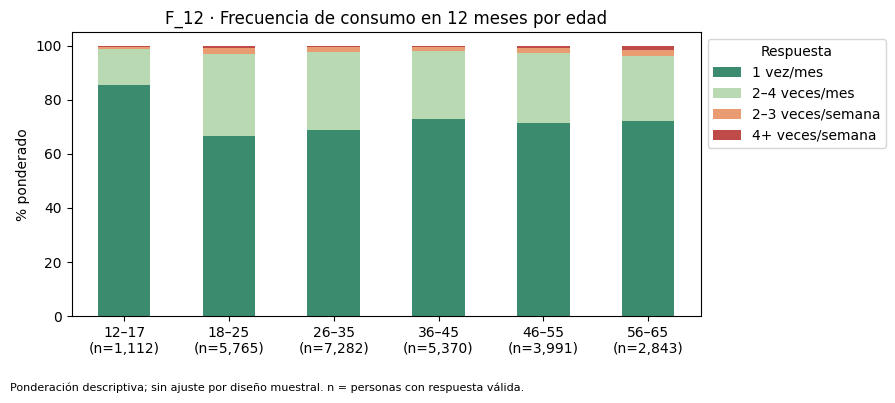

In [30]:
for variable in ['F_12 · Frecuencia de consumo en 12 meses']:
    sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
    sub[variable] = sub[variable].map({1: '1 vez/mes', 2: '2–4 veces/mes', 3: '2–3 veces/semana', 4: '4+ veces/semana'})
    sub = sub.dropna(subset=[variable, 'grupo_edad'])
    ponderada = pd.crosstab(sub[variable], sub.grupo_edad, values=sub.fex_c,
        aggfunc='sum', normalize='columns').reindex(['1 vez/mes', '2–4 veces/mes', '2–3 veces/semana', '4+ veces/semana']) * 100
    n = sub.groupby('grupo_edad', observed=True).size()
    ax = ponderada.T.plot(kind='bar', stacked=True, color=['#3b8c6e','#b8d9b1','#e99b72','#be4b48'], figsize=(9,4), rot=0)
    ax.set(title=variable + ' por edad', ylabel='% ponderado', xlabel='')
    ax.set_xticklabels([f'{g}\n(n={n[g]:,})' for g in ponderada.columns])
    ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Respuesta')
    ax.figure.text(.01,.01,'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.',fontsize=8)
    ax.figure.tight_layout(rect=(0,.06,1,1))
    display(ax.figure)
    plt.close(ax.figure)

**Interpretación.** La distribución completa de F_12 permite separar consumo mensual y semanal
en cada edad, evitando resumirlo todo como Sí/No. La frecuencia mensual predomina.
Este indicador mide periodicidad, a diferencia del desenlace binario F_06 de H2.

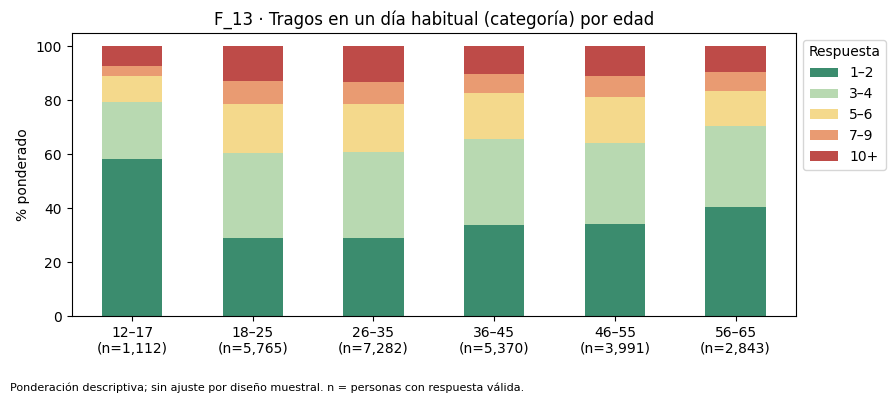

In [31]:
for variable in ['F_13 · Tragos en un día habitual (categoría)']:
    sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1)].copy()
    sub[variable] = sub[variable].map({1: '1–2', 2: '3–4', 3: '5–6', 4: '7–9', 5: '10+'})
    sub = sub.dropna(subset=[variable, 'grupo_edad'])
    ponderada = pd.crosstab(sub[variable], sub.grupo_edad, values=sub.fex_c,
        aggfunc='sum', normalize='columns').reindex(['1–2', '3–4', '5–6', '7–9', '10+']) * 100
    n = sub.groupby('grupo_edad', observed=True).size()
    ax = ponderada.T.plot(kind='bar', stacked=True, color=['#3b8c6e','#b8d9b1','#f4d98c','#e99b72','#be4b48'], figsize=(9,4), rot=0)
    ax.set(title=variable + ' por edad', ylabel='% ponderado', xlabel='')
    ax.set_xticklabels([f'{g}\n(n={n[g]:,})' for g in ponderada.columns])
    ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Respuesta')
    ax.figure.text(.01,.01,'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.',fontsize=8)
    ax.figure.tight_layout(rect=(0,.06,1,1))
    display(ax.figure)
    plt.close(ax.figure)

**Interpretación.** F_13 revela que cada grupo de edad incluye tanto cantidades bajas como altas
por ocasión. La presencia de categorías 7–9 y 10+ merece analizarse junto a F_14:
frecuencia de consumo y cantidad por ocasión no son dimensiones intercambiables.

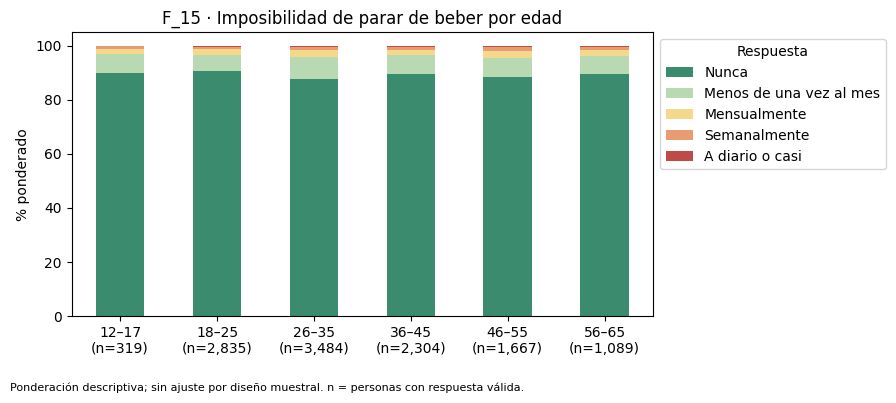

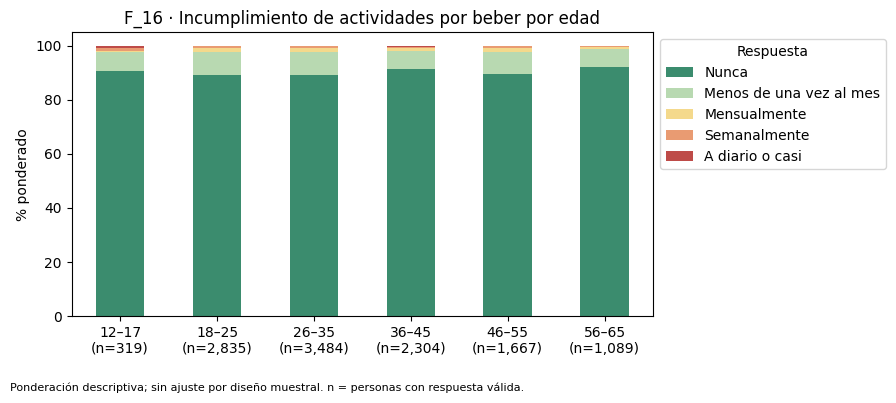

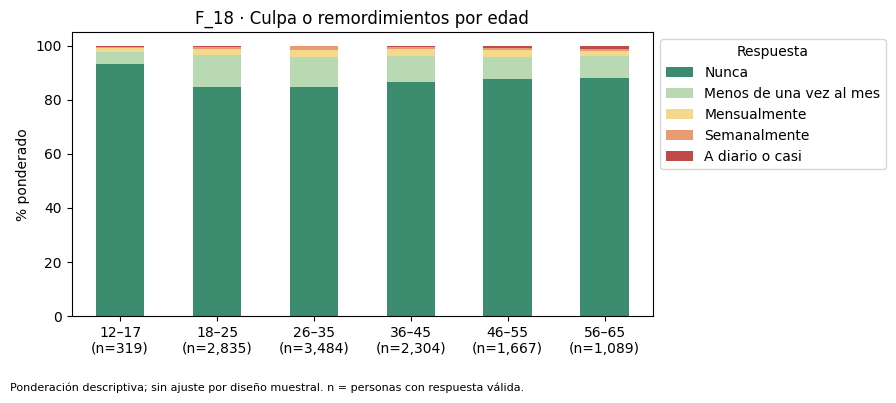

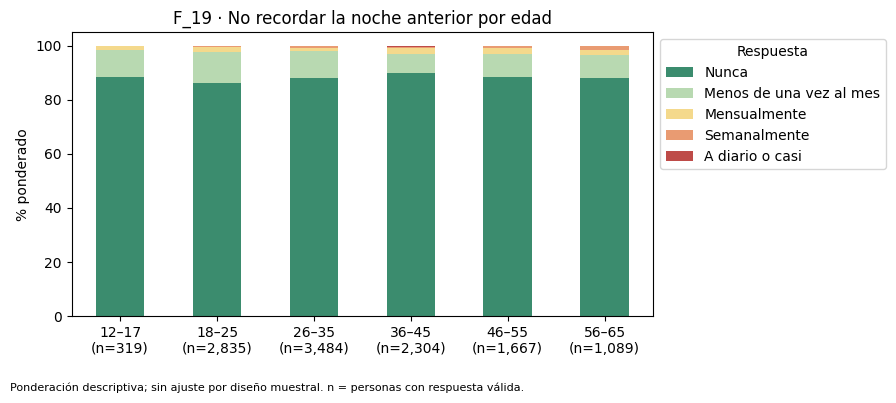

In [32]:
for variable in ['F_15 · Imposibilidad de parar de beber', 'F_16 · Incumplimiento de actividades por beber', 'F_18 · Culpa o remordimientos', 'F_19 · No recordar la noche anterior']:
    sub = df.loc[df['F_06 · Consumo en últimos 12 meses'].eq(1) & df['F_14 · Seis o más tragos en un día'].isin([2,3,4,5])].copy()
    sub[variable] = sub[variable].map({1: 'Nunca', 2: 'Menos de una vez al mes', 3: 'Mensualmente', 4: 'Semanalmente', 5: 'A diario o casi'})
    sub = sub.dropna(subset=[variable, 'grupo_edad'])
    ponderada = pd.crosstab(sub[variable], sub.grupo_edad, values=sub.fex_c,
        aggfunc='sum', normalize='columns').reindex(['Nunca', 'Menos de una vez al mes', 'Mensualmente', 'Semanalmente', 'A diario o casi']) * 100
    n = sub.groupby('grupo_edad', observed=True).size()
    ax = ponderada.T.plot(kind='bar', stacked=True, color=['#3b8c6e','#b8d9b1','#f4d98c','#e99b72','#be4b48'], figsize=(9,4), rot=0)
    ax.set(title=variable + ' por edad', ylabel='% ponderado', xlabel='')
    ax.set_xticklabels([f'{g}\n(n={n[g]:,})' for g in ponderada.columns])
    ax.legend(loc='upper left', bbox_to_anchor=(1,1), title='Respuesta')
    ax.figure.text(.01,.01,'Ponderación descriptiva; sin ajuste por diseño muestral. n = personas con respuesta válida.',fontsize=8)
    ax.figure.tight_layout(rect=(0,.06,1,1))
    display(ax.figure)
    plt.close(ax.figure)

**Interpretación.** En pérdida de control, incumplimiento, culpa y pérdida de memoria predomina Nunca
en todas las edades, con segmentos menores de síntomas reportados.
Las diferencias visuales pequeñas requieren cuidado: estas bases seleccionadas
no permiten concluir qué edad tiene mayor dependencia en la población general.

### F_10 · Bebidas × sexo y edad
Base: consumo de alcohol en 30 días, con respuesta 1–5 en cada bebida.
Se muestra consumo de esa bebida en 30 días (1–3), manteniendo 4–5 como No
para ese indicador. Una persona puede figurar en varias bebidas: no son cuotas
de mercado. Cada bebida tiene su propio denominador; los nulos de Otra permanecen desconocidos.
Se comparan cerveza, aguardiente, ron, whisky y vino por edad; por sexo se incluyen las ocho bebidas específicas; Otra va al anexo.

,Bebida,Sexo,n válido,% ponderado
0,Cerveza,Hombre,"8,165",85.8
1,Cerveza,Mujer,"6,371",76.2
2,Aguardiente,Hombre,"8,165",28.9
3,Aguardiente,Mujer,"6,371",24.5
4,Ron,Hombre,"8,165",19.2
5,Ron,Mujer,"6,371",16.7
6,Whisky,Hombre,"8,165",14.5
7,Whisky,Mujer,"6,371",10.0
8,"Brandy, coñac, vodka, ginebra",Hombre,"8,165",4.4
9,"Brandy, coñac, vodka, ginebra",Mujer,"6,371",4.3


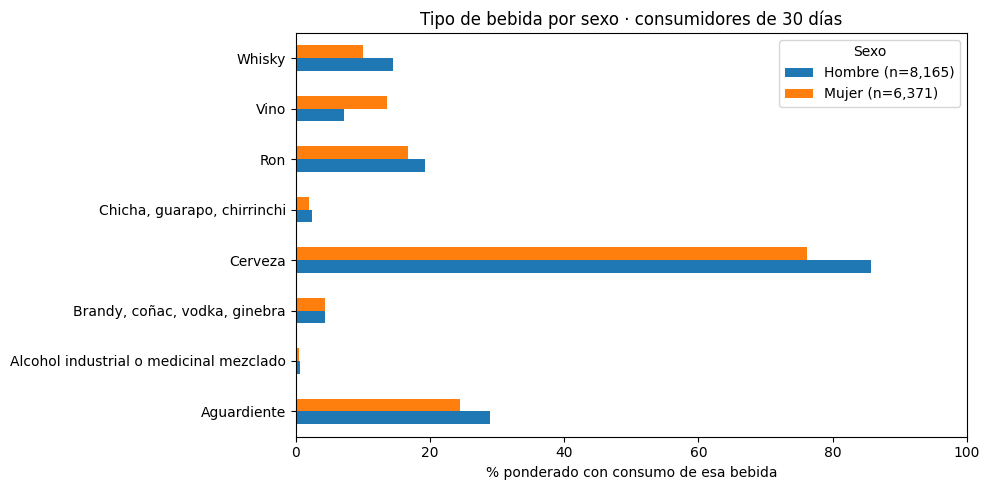

In [33]:
bebidas = []
for variable in df.filter(regex='^F_10_[A-H] ·').columns:
    sub = df.loc[df['F_07 · Consumo en últimos 30 días'].eq(1) & df[variable].isin([1,2,3,4,5])].copy()
    sub['Consume bebida en 30 días'] = sub[variable].isin([1,2,3])
    for sexo, grupo in sub.groupby('Sexo'):
        bebidas.append([variable.split(' · ')[1], sexo, len(grupo),
            100*np.average(grupo['Consume bebida en 30 días'], weights=grupo.fex_c)])
bebidas = pd.DataFrame(bebidas, columns=['Bebida','Sexo','n válido','% ponderado'])
display((bebidas.round(2)).style.format(precision=1, thousands=',', na_rep='—'))
ax = bebidas.pivot(index='Bebida',columns='Sexo',values='% ponderado').plot(
    kind='barh',figsize=(10,5), title='Tipo de bebida por sexo · consumidores de 30 días')
# Los ocho tipos tienen el mismo n válido dentro de cada sexo.
assert bebidas.groupby('Sexo')['n válido'].nunique().eq(1).all()
n = bebidas.groupby('Sexo')['n válido'].first()
ax.legend([f'{sexo} (n={n[sexo]:,})' for sexo in n.index], title='Sexo')
ax.set(xlabel='% ponderado con consumo de esa bebida', ylabel='', xlim=(0,100))
ax.figure.tight_layout()
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** La cerveza lidera el consumo reciente en ambos sexos; la combinación de bebidas
también varía por sexo. Los denominadores se indican una vez en la leyenda.
Las personas pueden consumir varias bebidas: los porcentajes no deben sumar 100%.

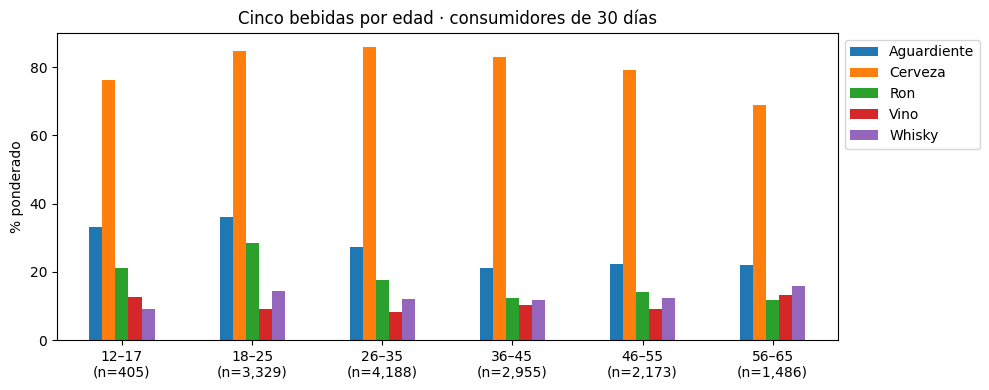

In [34]:
bebidas_edad = []
for variable in ['F_10_A · Cerveza', 'F_10_B · Aguardiente', 'F_10_C · Ron', 'F_10_D · Whisky', 'F_10_F · Vino']:
    sub = df.loc[df['F_07 · Consumo en últimos 30 días'].eq(1) & df[variable].isin([1,2,3,4,5])].copy()
    for edad, grupo in sub.groupby('grupo_edad', observed=True):
        bebidas_edad.append([variable.split(' · ')[1], edad, len(grupo),
            100*np.average(grupo[variable].isin([1,2,3]), weights=grupo.fex_c)])
bebidas_edad = pd.DataFrame(bebidas_edad, columns=['Bebida','Edad','n válido','% ponderado'])
ax = bebidas_edad.pivot(index='Edad',columns='Bebida',values='% ponderado').plot(
    kind='bar', figsize=(10,4), rot=0, title='Cinco bebidas por edad · consumidores de 30 días')
# En estas cinco bebidas los n coinciden dentro de cada edad; verificar antes de etiquetar.
assert bebidas_edad.groupby('Edad')['n válido'].nunique().eq(1).all()
n = bebidas_edad.groupby('Edad')['n válido'].first()
ax.set_xticklabels([f'{g}\n(n={n[g]:,})' for g in n.index])
ax.set(ylabel='% ponderado', xlabel='')
ax.legend(loc='upper left', bbox_to_anchor=(1,1))
ax.figure.tight_layout()
display(ax.figure)
plt.close(ax.figure)

**Interpretación.** La cerveza domina los cinco tipos comparados en todos los grupos de edad;
aguardiente y ron aportan otros patrones de preferencia. El n de cada edad
contextualiza la comparación. No se deduce riesgo solo del tipo de bebida:
faltan cantidad, concentración y contexto de cada ocasión.

### F_04, F_08 y F_09 · Spearman
Base común: consumo en 30 días, inicio y días válidos. Se excluyen del cruce los
casos con más días de embriaguez que de consumo. Correlación sin ponderar; las
tres parejas usan el mismo conjunto de casos completos.

In [35]:
sub = inicio.loc[inicio['F_07 · Consumo en últimos 30 días'].eq(1)
    & inicio['F_08 · Días de consumo en últimos 30 días'].between(1, 30)
    & inicio['F_09 · Días de embriaguez en últimos 30 días'].between(0, 30)
    & inicio['F_08 · Días de consumo en últimos 30 días'].eq(inicio['F_08 · Días de consumo en últimos 30 días'].round())
    & inicio['F_09 · Días de embriaguez en últimos 30 días'].eq(inicio['F_09 · Días de embriaguez en últimos 30 días'].round())
    & inicio['F_09 · Días de embriaguez en últimos 30 días'].le(inicio['F_08 · Días de consumo en últimos 30 días']),
    ['F_04 · Edad de inicio del consumo', 'F_08 · Días de consumo en últimos 30 días', 'F_09 · Días de embriaguez en últimos 30 días']].dropna()
print(f'n válido común: {len(sub):,}')
display((sub.corr(method='spearman')).style.format(precision=2, na_rep='—').background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))

n válido común: 14,448


,F_04 · Edad de inicio del consumo,F_08 · Días de consumo en últimos 30 días,F_09 · Días de embriaguez en últimos 30 días
F_04 · Edad de inicio del consumo,1.00,-0.16,-0.12
F_08 · Días de consumo en últimos 30 días,-0.16,1.00,0.28
F_09 · Días de embriaguez en últimos 30 días,-0.12,0.28,1.00


**Interpretación.** Spearman es aproximadamente −0.16 entre inicio y días de consumo, −0.12 entre
inicio y embriaguez, y 0.28 entre ambos conteos de días. Son relaciones débiles;
el inicio temprano coincide modestamente con más días, sin demostrar causalidad.
Las correlaciones son muestrales y se calculan sobre la misma base completa.

### Síntesis de patrones
“Mayor” se refiere al porcentaje dentro de la base de cada cruce; F_04 compara
años. El n es el total válido del cruce. Las hipótesis surgen de este EDA y
requieren validación posterior.

In [36]:
resumen = pd.DataFrame([
    ['F_14 6+ tragos en un solo día (binge) × edad', f"Binge mensual: {binge_edad['% ponderado'].min():.1f}–{binge_edad['% ponderado'].max():.1f}%",
     binge_edad['% ponderado'].idxmax(), int(binge_edad.n_valido.sum())],
    ['F_14 6+ tragos en un solo día (binge) × sexo', f"Binge mensual: {binge_sexo['% ponderado'].min():.1f}–{binge_sexo['% ponderado'].max():.1f}%",
     binge_sexo['% ponderado'].idxmax(), int(binge_sexo.n_valido.sum())],
    ['F_14 6+ tragos en un solo día (binge) × educación', f"Binge mensual: {binge_educacion['% ponderado'].min():.1f}–{binge_educacion['% ponderado'].max():.1f}%",
     binge_educacion['% ponderado'].idxmax(), int(binge_educacion.n_valido.sum())],
    ['F_17 Necesidad de beber en ayunas (dependencia) × edad', f"Ayunas alguna frecuencia: {ayunas_edad['% ponderado'].min():.1f}–{ayunas_edad['% ponderado'].max():.1f}%",
     ayunas_edad['% ponderado'].idxmax(), int(ayunas_edad.n_valido.sum())],
    ['F_01 Familiares que se emborrachan frecuentemente × F_06 Consumo últimos 12 meses', f"Consumo anual: {entorno_familiar['% ponderado'].min():.1f}–{entorno_familiar['% ponderado'].max():.1f}%",
     entorno_familiar['% ponderado'].idxmax(), int(entorno_familiar.n_valido.sum())],
    ['F_02 Amigos que se emborrachan frecuentemente × F_06 Consumo últimos 12 meses', f"Consumo anual: {entorno_social['% ponderado'].min():.1f}–{entorno_social['% ponderado'].max():.1f}%",
     entorno_social['% ponderado'].idxmax(), int(entorno_social.n_valido.sum())],
    ['F_04 Edad del primer consumo × sexo', f"Inicio medio: {inicio_sexo['Edad media ponderada'].min():.1f}–{inicio_sexo['Edad media ponderada'].max():.1f} años",
     inicio_sexo['Edad media ponderada'].idxmax(), int(inicio_sexo.n_valido.sum())]
], columns=['Variable', 'Patrón observado (ponderado)', 'Grupo con mayor % / media', 'n válido'])
display((resumen).style.format(precision=1, thousands=',', na_rep='—'))

,Variable,Patrón observado (ponderado),Grupo con mayor % / media,n válido
0,F_14 6+ tragos en un solo día (binge) × edad,Binge mensual: 6.2–17.4%,26–35,"26,363"
1,F_14 6+ tragos en un solo día (binge) × sexo,Binge mensual: 8.4–19.2%,Hombre,"26,363"
2,F_14 6+ tragos en un solo día (binge) × educación,Binge mensual: 10.0–18.5%,Primaria,"26,353"
3,F_17 Necesidad de beber en ayunas (dependencia) × edad,Ayunas alguna frecuencia: 2.6–5.9%,18–25,"11,698"
4,F_01 Familiares que se emborrachan frecuentemente × F_06 Consumo últimos 12 meses,Consumo anual: 62.6–69.4%,Sí,"42,389"
5,F_02 Amigos que se emborrachan frecuentemente × F_06 Consumo últimos 12 meses,Consumo anual: 57.6–73.7%,Sí,"42,389"
6,F_04 Edad del primer consumo × sexo,Inicio medio: 16.8–18.7 años,Mujer,"42,441"


**Interpretación.** La síntesis distingue máximos dentro de cada cruce, no indicadores comparables
entre sí: cambian las bases y las unidades. El patrón más claro para profundizar
es la diferencia de binge por sexo y edad; entorno social e inicio aportan
hipótesis complementarias, todavía marginales.

## Anexo · F_10_I, Otra bebida
Hay **624 respuestas válidas**; 7 es el conteo de la categoría Diariamente,
no el total de la variable. Los restantes faltantes dentro de consumidores de
30 días no se interpretan como Nunca. Se conserva aquí para transparencia,
sin usarla para formular hipótesis.

In [37]:
sub = df.loc[df['F_07 · Consumo en últimos 30 días'].eq(1)].copy()
sub['F_10_I · Otra bebida'] = sub['F_10_I · Otra bebida'].map({
    1:'Diariamente',2:'Fines de semana',3:'Algunos días de la semana',
    4:'No en últimos 30 días',5:'Nunca'})
display((pct_ponderado(sub, 'F_10_I · Otra bebida').round(2)).style.format(precision=1, thousands=',', na_rep='—').background_gradient(subset=['pct_muestral','pct_ponderado'], cmap='YlOrRd', vmin=0, vmax=100))

,pct_muestral,pct_ponderado,n_valido
F_10_I · Otra bebida,,,
Algunos días de la semana,6.9,7.3,43
Diariamente,1.1,1.0,7
Fines de semana,16.2,17.1,101
No en últimos 30 días,75.8,74.7,473


**Interpretación.** Otra bebida tiene 624 respuestas válidas; solo siete corresponden a consumo diario.
Su escasa cobertura y los faltantes impiden interpretarla como una bebida homogénea
o compararla directamente con las ocho categorías específicas.

## Cierre e hipótesis propuestas

**H1 — Binge y sexo.** Entre consumidores de los últimos 12 meses, el binge al
menos mensual (F_14) es más frecuente en hombres que en mujeres:
**19.19% frente a 8.41% ponderado**. La diferencia es 10.78 puntos porcentuales.

**H2 — Entorno social y consumo anual.** Entre quienes han consumido alcohol
alguna vez, tener amigos que se emborrachan frecuentemente (F_02) se asocia con
una **mayor probabilidad (prevalencia) de haber consumido en los últimos 12 meses**
(F_06): **73.66% frente a 57.64% ponderado**. V de Cramér es **≈0.177**, una
asociación débil; 0.164 corresponde al cruce de H1. Un p pequeño en el chi-cuadrado
simple no significa relación fuerte ni confirma significancia bajo el diseño real.

**H3 — Inicio y sexo.** Entre quienes consumieron alguna vez, la edad de inicio
(F_04) es más temprana en hombres: **16.83 frente a 18.72 años ponderados**.
La diferencia ronda 1.89 años y puede reflejar edad actual, cohortes y recuerdo.

Estas hipótesis se formularon después de explorar los datos; describen
**asociaciones marginales**, no efectos ajustados ni causales. El siguiente paso
es un análisis con diseño complejo: Rao–Scott para asociaciones categóricas
([samplics](https://samplics-org.github.io/samplics/pages/categorical_tabulation.html)
o [survey](https://r-survey.r-forge.r-project.org/survey/html/svychisq.html)),
y un contraste de medias/regresión de encuesta para H3.

Se necesitan FEX_C, el **estrato del diseño** y la **UPM/conglomerado real**, o
pesos replicados. No debe suponerse que ESTRATO/EST_Socio son estratos de diseño,
ni que DIRECTORIO identifica la UPM: esas correspondencias deben verificarse
en la documentación. Disponer solo de FEX_C no resuelve la varianza de diseño.

## Discusión y recomendaciones

**Mensaje preliminar al Ministerio de Salud.** El patrón observado justifica
investigar con mayor detalle a hombres de 18–35 años, donde se concentra la
mayor proporción de binge entre consumidores anuales. Esto puede orientar la
evaluación de prevención y detección temprana, manteniendo cobertura para mujeres,
adolescentes y otros grupos; no demuestra que una intervención concreta sea eficaz.

El entorno social ofrece una segunda línea: evaluar estrategias que consideren
redes de amigos y contextos de consumo. H2 no permite distinguir influencia de
amigos, selección de amistades o factores compartidos, por lo que no fundamenta
atribuir responsabilidad causal a esas redes.

Antes de priorizar recursos, estimar prevalencias e intervalos con el diseño
muestral, contrastar las hipótesis con ajuste por confusión y revisar calidad de
edades de inicio. La información es de **2019**: describe ese periodo y esa cobertura,
no automáticamente la situación actual. El aporte del EDA es proponer preguntas
contrastables, no presentar estas recomendaciones como conclusiones definitivas.